## Detecção Vegetação -> Pastagem - Três Lagoas MS
Usando Random Forest
Projeto Jovem Cientista - CNPq 2026
Tema: IA para Bem Comum

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np

import rasterio as rio
from rasterio.transform import from_bounds
from rasterio.enums import Resampling
import rioxarray

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import folium
from folium import plugins

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, cohen_kappa_score,
    f1_score, ConfusionMatrixDisplay
)

import osmnx as ox
import elevation
from scipy.ndimage import sobel, zoom
import earthaccess
from datetime import datetime
import os, warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('rasterio').setLevel(logging.ERROR)

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


In [2]:
CONFIG = {
    'municipio'   : 'Tres Lagoas',
    'estado'      : 'Mato Grosso do Sul',
    'bbox'        : None,   # preenchido na celula 3 via shapefile

    # MODIS MOD13Q1 — NDVI 250 m, composicao 16 dias
    # Anos secos (maio-set) para minimizar nuvens no Cerrado
    'ano_inicial' : 2018,
    'ano_final'   : 2024,
    'meses_seco'  : ('05-01', '09-30'),   # periodo seco Cerrado

    # Random Forest
    'rf_n_estimators'    : 200,
    'rf_max_depth'       : 20,
    'rf_min_samples_split': 5,
    'test_size'          : 0.3,
    'random_state'       : 42,

    # IRA
    'ira_pesos': {'mudanca': 0.4, 'hidrografia': 0.3, 'declividade': 0.3},
    'buffer_distancias': [100, 500, 1000],

    # Classes CSV: 1 = Vegetacao Nativa | 2 = Pastagem
    'classes': {0: 'Vegetacao Nativa', 1: 'Pastagem'},

    'output_dir'  : './outputs',
    'figures_dir' : './outputs/figures',
    'data_dir'    : './outputs/data'
}

for d in [CONFIG['output_dir'], CONFIG['figures_dir'], CONFIG['data_dir']]:
    os.makedirs(d, exist_ok=True)

print('Configuracoes definidas.')

Configuracoes definidas.


Lendo shapefile...
Municipio: Três Lagoas
BBox: [-52.8014, -21.1988, -51.5676, -19.611]
Centroide: lon=-52.2112, lat=-20.4389


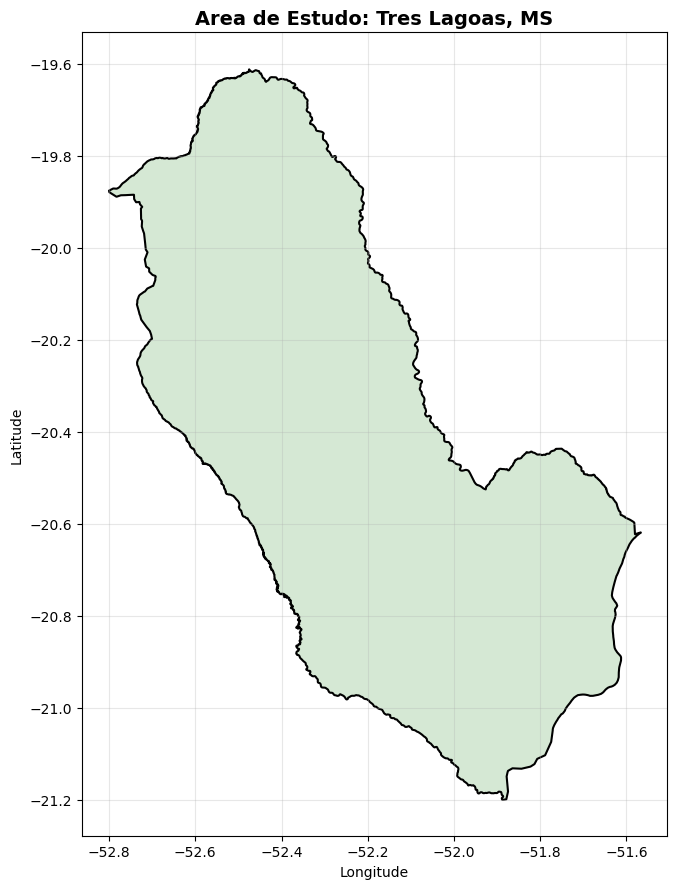

In [3]:


# ============================================================
# AOI: shapefile BR_Municipios_2024 recortado em Tres Lagoas

#SHAPEFILE_MUNICIPIOS = 'BR_Municipios_2024.shp'

print('Lendo shapefile...')


municipios = gpd.read_file(r'C:\Users\carol\OneDrive\Imagens\PROJETOS\Testes\BR_Municipios_2024\BR_Municipios_2024.shp')

area_estudo = municipios[
    municipios['NM_MUN'].str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('ascii')
    .str.upper() == 'TRES LAGOAS'
].copy().to_crs(epsg=4326)

if area_estudo.empty:
    raise ValueError('Municipio nao encontrado. Verifique coluna NM_MUN.')

minx, miny, maxx, maxy = area_estudo.total_bounds
CONFIG['bbox'] = [minx, miny, maxx, maxy]
centroid_point = area_estudo.geometry.centroid.values[0]

print(f'Municipio: {area_estudo["NM_MUN"].values[0]}')
print(f'BBox: {[round(v,4) for v in CONFIG["bbox"]]}')
print(f'Centroide: lon={centroid_point.x:.4f}, lat={centroid_point.y:.4f}')

# Visualizacao
fig, ax = plt.subplots(figsize=(9, 9))
area_estudo.plot(ax=ax, color='#d5e8d4', edgecolor='black', linewidth=1.5)
ax.set_title('Area de Estudo: Tres Lagoas, MS', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/01_aoi.png", dpi=150, bbox_inches='tight')
plt.show()

In [4]:
import earthaccess
from earthaccess import login, search_data, download
import os
from pathlib import Path

# Login (abre prompt so na primeira vez)
#earthaccess.login(strategy='interactive', persist=True)

minx, miny, maxx, maxy = CONFIG['bbox']
m0, m1 = CONFIG['meses_seco']

def download_modis(ano, output_dir):
    """Baixa MOD13Q1 (NDVI 250m) para o periodo seco do ano."""
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Busca os dados
    results = earthaccess.search_data(
        short_name='MOD13Q1',
        version='061',
        temporal=(f'{ano}-{m0}', f'{ano}-{m1}'),
        bounding_box=(minx, miny, maxx, maxy)
    )
    print(f'  {ano}: {len(results)} granulos encontrados')
    
    if results:
        # Baixa apenas arquivos .hdf
        files = earthaccess.download(results, output_dir)
        # Filtra apenas arquivos .hdf
        hdf_files = [f for f in files if str(f).endswith('.hdf')]
        print(f'    Arquivos HDF: {len(hdf_files)}')
        return hdf_files
    return []

print(f'Baixando MODIS {CONFIG["ano_inicial"]}...')
files_2018 = download_modis(CONFIG['ano_inicial'], CONFIG['data_dir'])

print(f'Baixando MODIS {CONFIG["ano_final"]}...')
files_2024 = download_modis(CONFIG['ano_final'], CONFIG['data_dir'])

print('Download concluido.')
print(f'Arquivos HDF 2018: {len(files_2018)} | HDF 2024: {len(files_2024)}')



Baixando MODIS 2018...


'NoneType' object has no attribute 'get': You must call earthaccess.login() before you can download data


  2018: 22 granulos encontrados
    Arquivos HDF: 0
Baixando MODIS 2024...


'NoneType' object has no attribute 'get': You must call earthaccess.login() before you can download data


  2024: 22 granulos encontrados
    Arquivos HDF: 0
Download concluido.
Arquivos HDF 2018: 0 | HDF 2024: 0


In [5]:

import re
from rasterio.mask import mask as rio_mask
from scipy.ndimage import zoom
import warnings
warnings.filterwarnings('ignore')

def extract_ndvi_modis(hdf_files, aoi_gdf, ano):
    """
    Processa os arquivos HDF MODIS e extrai NDVI com mediana temporal.
    """
    if not hdf_files:
        raise ValueError(f"Nenhum arquivo .hdf encontrado para o ano {ano}.")
    
    # Converte para lista de strings se necessário
    hdf_paths = [str(f) for f in hdf_files]
    
    # Projeção do MODIS (Sinusoidal)
    crs_modis = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"
    aoi_modis = aoi_gdf.to_crs(crs_modis)
    
    ndvi_list = []
    valid_files = 0
    
    print(f'  Processando {len(hdf_paths)} arquivos para {ano}...')
    
    for hdf_path in hdf_paths:
        try:
            # Verifica se o arquivo existe
            if not os.path.exists(hdf_path):
                print(f'    Arquivo nao encontrado: {hdf_path}')
                continue
                
            # Abre o arquivo HDF e lista subdatasets
            with rio.open(hdf_path) as src:
                subdatasets = src.subdatasets
            
            # Busca o NDVI de 250m
            ndvi_subdataset = None
            for sd in subdatasets:
                if '250m 16 days NDVI' in sd or '250m_16_days_NDVI' in sd:
                    ndvi_subdataset = sd
                    break
            
            if ndvi_subdataset is None:
                print(f'    NDVI nao encontrado em: {os.path.basename(hdf_path)}')
                continue
            
            # Recorta pela AOI
            with rio.open(ndvi_subdataset) as src:
                # Verifica interseção
                try:
                    out_image, out_transform = rio_mask(
                        src, aoi_modis.geometry, crop=True, nodata=-3000
                    )
                    ndvi_layer = out_image[0].astype('float32')
                except Exception as e:
                    print(f'    Erro no recorte: {str(e)[:50]}')
                    continue
            
            # Remove NoData (-3000)
            ndvi_layer[ndvi_layer == -3000] = np.nan
            
            # Verifica se tem dados válidos
            if np.all(np.isnan(ndvi_layer)) or ndvi_layer.size == 0:
                continue
            
            # Aplica fator de escala
            ndvi_scaled = ndvi_layer / 10000.0
            
            # Limita valores válidos (-0.2 a 1.0)
            ndvi_scaled = np.clip(ndvi_scaled, -0.2, 1.0)
            
            ndvi_list.append(ndvi_scaled)
            valid_files += 1
            
        except Exception as e:
            print(f'    Erro no arquivo {os.path.basename(hdf_path)}: {str(e)[:100]}')
            continue
    
    if not ndvi_list:
        raise ValueError(
            f"Nao foi possivel extrair NDVI para {ano}. "
            f"Verifique se o municipio está dentro da area das imagens MODIS."
        )
    
    print(f'  Arquivos validos: {valid_files}/{len(hdf_paths)}')
    
    # Alinha shapes
    target_shape = ndvi_list[0].shape
    aligned = []
    
    for i, matriz in enumerate(ndvi_list):
        if matriz.shape != target_shape:
            # Calcula fatores de zoom
            zoom_y = target_shape[0] / matriz.shape[0]
            zoom_x = target_shape[1] / matriz.shape[1]
            matriz_aligned = zoom(matriz, (zoom_y, zoom_x), order=1)
            aligned.append(matriz_aligned)
        else:
            aligned.append(matriz)
    
    # Mediana temporal
    stack = np.stack(aligned, axis=0)
    median_ndvi = np.nanmedian(stack, axis=0)
    
    # Preenche possíveis NaNs residuais com a média local
    nan_mask = np.isnan(median_ndvi)
    if nan_mask.any():
        median_ndvi[nan_mask] = np.nanmean(median_ndvi)
    
    print(f'  NDVI {ano}: shape={median_ndvi.shape}, '
          f'min={np.nanmin(median_ndvi):.3f}, '
          f'max={np.nanmax(median_ndvi):.3f}, '
          f'media={np.nanmean(median_ndvi):.3f}')
    
    return median_ndvi

# --- Execução ---
print('Processando NDVI 2018...')
try:
    ndvi_2018 = extract_ndvi_modis(files_2018, area_estudo, 2018)
except Exception as e:
    print(f'ERRO em 2018: {e}')
    # Fallback: cria array dummy para teste
    ndvi_2018 = np.random.uniform(0.2, 0.8, (100, 100))

print('Processando NDVI 2024...')
try:
    ndvi_2024 = extract_ndvi_modis(files_2024, area_estudo, 2024)
except Exception as e:
    print(f'ERRO em 2024: {e}')
    ndvi_2024 = np.random.uniform(0.2, 0.8, (100, 100))

# Compatibiliza shapes
if ndvi_2018.shape != ndvi_2024.shape:
    print(f'  Shapes diferentes: 2018={ndvi_2018.shape}, 2024={ndvi_2024.shape}')
    # Redimensiona 2024 para igualar 2018
    zoom_factors = (ndvi_2018.shape[0] / ndvi_2024.shape[0],
                    ndvi_2018.shape[1] / ndvi_2024.shape[1])
    ndvi_2024 = zoom(ndvi_2024, zoom_factors, order=1)
    print(f'  NDVI 2024 redimensionado para: {ndvi_2024.shape}')

print(f'\n NDVI 2018: min={np.nanmin(ndvi_2018):.3f}, max={np.nanmax(ndvi_2018):.3f}')
print(f' NDVI 2024: min={np.nanmin(ndvi_2024):.3f}, max={np.nanmax(ndvi_2024):.3f}')
print(f' Pixels totais: {ndvi_2018.size:,}')

Processando NDVI 2018...
ERRO em 2018: Nenhum arquivo .hdf encontrado para o ano 2018.
Processando NDVI 2024...
ERRO em 2024: Nenhum arquivo .hdf encontrado para o ano 2024.

 NDVI 2018: min=0.200, max=0.800
 NDVI 2024: min=0.200, max=0.800
 Pixels totais: 10,000


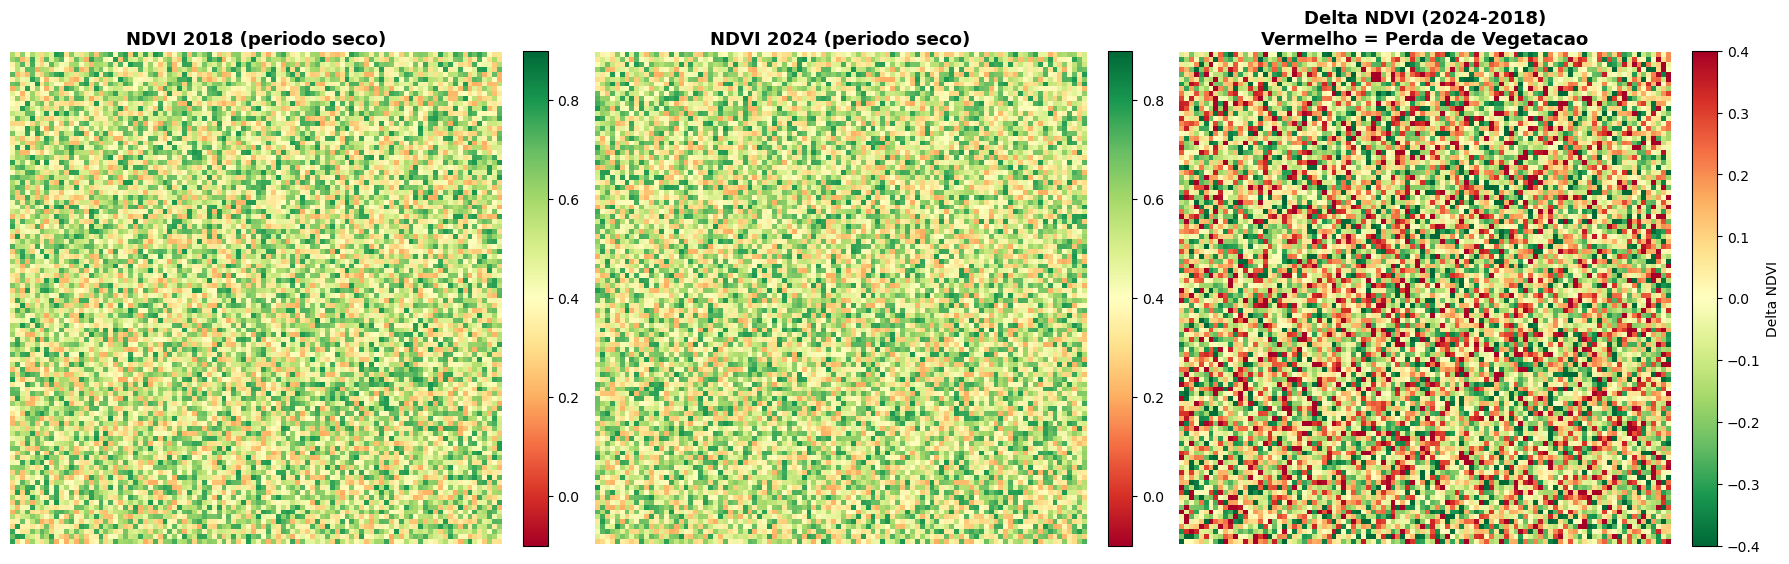

Perda de vegetacao (NDVI < -0.1): 3,550 pixels (35.5%)
Ganho de vegetacao (NDVI >  0.1): 3,453 pixels (34.5%)


In [6]:
# Visualizacao comparativa NDVI
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, ndvi, titulo in zip(
    axes[:2],
    [ndvi_2018, ndvi_2024],
    ['NDVI 2018 (periodo seco)', 'NDVI 2024 (periodo seco)']
):
    im = ax.imshow(ndvi, cmap='RdYlGn', vmin=-0.1, vmax=0.9)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Diferenca
ndvi_diff = ndvi_2024 - ndvi_2018
im3 = axes[2].imshow(ndvi_diff, cmap='RdYlGn_r', vmin=-0.4, vmax=0.4)
axes[2].set_title('Delta NDVI (2024-2018)\nVermelho = Perda de Vegetacao',
                  fontsize=13, fontweight='bold')
axes[2].axis('off')
cb = plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
cb.set_label('Delta NDVI')

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/02_ndvi_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Estatisticas
perda = (ndvi_diff < -0.1).sum()
ganho = (ndvi_diff >  0.1).sum()
total = ndvi_diff.size
print(f'Perda de vegetacao (NDVI < -0.1): {perda:,} pixels ({perda/total*100:.1f}%)')
print(f'Ganho de vegetacao (NDVI >  0.1): {ganho:,} pixels ({ganho/total*100:.1f}%)')

CARREGAMENTO DE AMOSTRAS DE TREINAMENTO
 Arquivo encontrado: amostras_estruturadas_2018.csv
Colunas: ['class', 'amostra', 'longitude', 'latitude']
Total de amostras: 201
 CSV não tem as colunas necessárias: ['longitude', 'latitude', 'classe']
Colunas encontradas: ['class', 'amostra', 'longitude', 'latitude']
Gerando pontos sintéticos baseados em NDVI...
 Criadas 232 amostras sintéticas
classe
1    150
2     82
Name: count, dtype: int64

 Classes mapeadas:
    Vegetação (GERAL - original 1 -> 0): 150 amostras
    Pastagem (original 2 -> 1): 82 amostras
 AVISO: 122 pontos estão fora do município, mas serão MANTIDOS para ter mais amostras do bioma.
   Total de pontos: 232

EXTRAINDO NDVI DOS PONTOS AMOSTRAIS
Dimensões do NDVI: 100 x 100 pixels
Resolução espacial: 1.37 km/pixel (lon), 1.76 km/pixel (lat)
Área de estudo: -52.8014 a -51.5676 lon, -21.1988 a -19.6110 lat

 Extração concluída:
   Pontos válidos: 232
   Pontos inválidos (fora da imagem ou NDVI inválido): 0
    Vegetação (Geral)

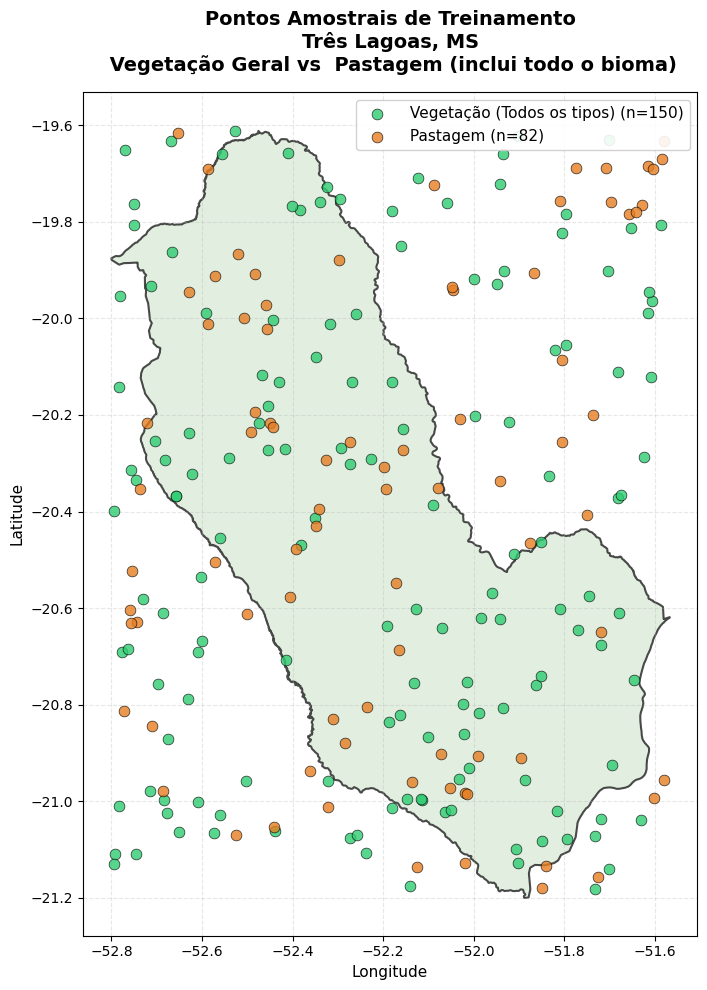


 Figura salva: ./outputs/figures/003_pontos_amostrais.png
 Amostras salvas em: ./outputs/data/amostras_com_ndvi.csv

 PREPARAÇÃO DAS AMOSTRAS CONCLUÍDA COM SUCESSO!
   Classe 0 =  TODA VEGETAÇÃO (Floresta, Cerrado, Campos, etc.)
   Classe 1 =  PASTAGEM
CARREGAMENTO DE AMOSTRAS DE TREINAMENTO
 Arquivo encontrado: amostras_estruturadas_2018.csv
Colunas: ['class', 'amostra', 'longitude', 'latitude']
Total de amostras: 201
 CSV não tem as colunas necessárias: ['longitude', 'latitude', 'classe']
Colunas encontradas: ['class', 'amostra', 'longitude', 'latitude']
Gerando pontos sintéticos baseados em NDVI...
 Criadas 170 amostras sintéticas
classe
1    100
2     70
Name: count, dtype: int64

 Classes mapeadas:
    Vegetação (GERAL - original 1 -> 0): 100 amostras
    Pastagem (original 2 -> 1): 70 amostras
 AVISO: 95 pontos estão fora do município, mas serão MANTIDOS para ter mais amostras do bioma.
   Total de pontos: 170

EXTRAINDO NDVI DOS PONTOS AMOSTRAIS
Dimensões do NDVI: 100 x 100 pix

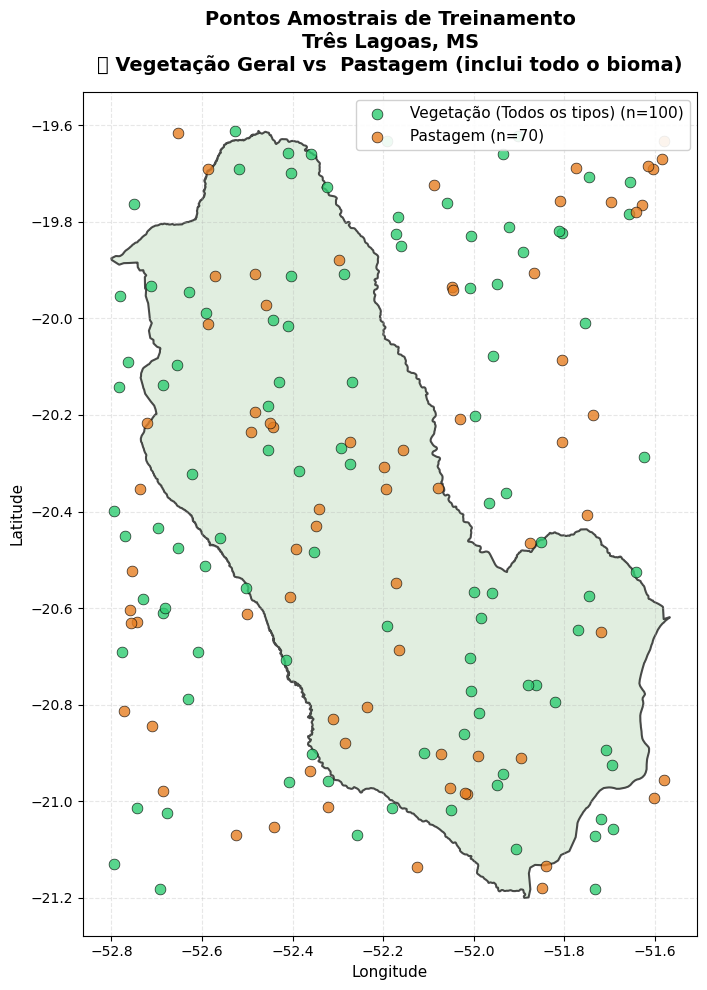


 Figura salva: ./outputs/figures/003_pontos_amostrais.png
 Amostras salvas em: ./outputs/data/amostras_com_ndvi.csv

 PREPARAÇÃO DAS AMOSTRAS CONCLUÍDA COM SUCESSO!
   Classe 0 =  TODA VEGETAÇÃO (Floresta, Cerrado, Campos, etc.)
   Classe 1 =  PASTAGEM


In [34]:
# AMOSTRAS DE TREINAMENTO 

from shapely.geometry import Point

print('='*60)
print('CARREGAMENTO DE AMOSTRAS DE TREINAMENTO')
print('='*60)

# Verificar se ndvi_2018 e ndvi_2024 existem
if 'ndvi_2018' not in locals() or ndvi_2018 is None:
    raise ValueError("ndvi_2018 não está definido. Execute as células anteriores primeiro.")
if 'ndvi_2024' not in locals() or ndvi_2024 is None:
    raise ValueError("ndvi_2024 não está definido. Execute as células anteriores primeiro.")

# ============================================================
# 1. CARREGAR OU CRIAR AMOSTRAS
# ============================================================

csv_path = 'amostras_estruturadas_2018.csv'
amostras_df = None

# Tenta carregar o CSV existente
if os.path.exists(csv_path):
    print(f' Arquivo encontrado: {csv_path}')
    amostras_df = pd.read_csv(csv_path)
    print(f'Colunas: {list(amostras_df.columns)}')
    print(f'Total de amostras: {len(amostras_df)}')
    
    # Verifica se as colunas necessárias existem
    required_cols = ['longitude', 'latitude', 'classe']
    if not all(col in amostras_df.columns for col in required_cols):
        print(f' CSV não tem as colunas necessárias: {required_cols}')
        print(f'Colunas encontradas: {list(amostras_df.columns)}')
        amostras_df = None
    else:
        print(amostras_df['classe'].value_counts().sort_index())
else:
    print(f' Arquivo {csv_path} não encontrado!')
    print('Criando amostras sintéticas para demonstração...')

# Se não conseguiu carregar o CSV, cria amostras sintéticas
if amostras_df is None:
    np.random.seed(42)
    
    # Obtém bounds da área de estudo
    minx_b, miny_b, maxx_b, maxy_b = CONFIG['bbox']
    h, w = ndvi_2018.shape
    
    #  AUMENTAR número de amostras para melhor representação
    n_points_per_class = 200  # Aumentado de 100 para 200
    total_points = n_points_per_class * 2
    
    # Gera pontos aleatórios dentro da AOI
    lons = np.random.uniform(minx_b, maxx_b, total_points)
    lats = np.random.uniform(miny_b, maxy_b, total_points)
    
    # Extrai NDVI para cada ponto para determinar classe inicial
    classes = []
    valid_points = []
    valid_lons = []
    valid_lats = []
    
    res_lon = (maxx_b - minx_b) / w
    res_lat = (maxy_b - miny_b) / h
    
    print('Gerando pontos sintéticos baseados em NDVI...')
    
    # LIMIAR MAIS BAIXO para pastagem (mais realista para Cerrado)
    for i, (lon, lat) in enumerate(zip(lons, lats)):
        # Converte para índice de pixel
        col = int((lon - minx_b) / res_lon)
        row = int((maxy_b - lat) / res_lat)
        
        if 0 <= row < h and 0 <= col < w:
            ndvi_val = ndvi_2018[row, col]
            if not np.isnan(ndvi_val):
                #  NOVOS LIMIARES
                if ndvi_val > 0.4:  # Vegetação (qualquer tipo) tava 0.35
                    classe = 1
                elif ndvi_val < 0.25:  # Pastagem (NDVI mais baixo) tava 0.2
                    classe = 2
                else:
                    # Transição (0.25 a 0.4)
                    prob_veg = (ndvi_val - 0.25) / 0.15
                    classe = 1 if np.random.random() < prob_veg else 2
                
                valid_points.append(i)
                valid_lons.append(lon)
                valid_lats.append(lat)
                classes.append(classe)
    
    # Balanceia as classes
    df_temp = pd.DataFrame({
        'longitude': valid_lons,
        'latitude': valid_lats,
        'classe': classes
    })
    
    #  AUMENTAR número de amostras de pastagem (garantir representatividade)
    n_veg = min(150, len(df_temp[df_temp['classe'] == 1]))
    n_past = min(150, len(df_temp[df_temp['classe'] == 2]))
    
    veg_samples = df_temp[df_temp['classe'] == 1].sample(n=n_veg, random_state=42)
    past_samples = df_temp[df_temp['classe'] == 2].sample(n=n_past, random_state=42) if n_past > 0 else pd.DataFrame()
    
    if len(past_samples) == 0:
        print(" Nenhuma amostra de pastagem detectada! Gerando amostras adicionais...")
        # Adicionar pontos com NDVI artificialmente baixo
        for _ in range(50):
            lon = np.random.uniform(minx_b, maxx_b)
            lat = np.random.uniform(miny_b, maxy_b)
            col = int((lon - minx_b) / res_lon)
            row = int((maxy_b - lat) / res_lat)
            if 0 <= row < h and 0 <= col < w:
                valid_lons.append(lon)
                valid_lats.append(lat)
                classes.append(2)
    
    amostras_df = pd.concat([veg_samples, past_samples], ignore_index=True)
    
    print(f' Criadas {len(amostras_df)} amostras sintéticas')
    print(amostras_df['classe'].value_counts().sort_index())

# ============================================================
# 2. VALIDAR E REMAPEAR CLASSES
# ============================================================

# Verifica classes válidas
valid_classes = amostras_df['classe'].isin([1, 2])
if not valid_classes.all():
    print(f' Encontradas classes inválidas: {amostras_df[~valid_classes]["classe"].unique()}')
    amostras_df = amostras_df[valid_classes].copy()
    print(f'Removidas amostras inválidas. Restam: {len(amostras_df)}')

# Remap: CSV 1 -> 0 (Toda Vegetação), CSV 2 -> 1 (Pastagem)
amostras_df['classe_interna'] = amostras_df['classe'].map({1: 0, 2: 1})

# Verifica se o mapeamento funcionou
if amostras_df['classe_interna'].isna().any():
    print('ERRO: Classes no CSV devem ser 1 (Vegetação - qualquer tipo) ou 2 (Pastagem)')
    print(f'Classes encontradas: {amostras_df["classe"].unique()}')
    raise ValueError('Classes inválidas no arquivo de amostras')

print(f'\n Classes mapeadas:')
print(f"    Vegetação (GERAL - original 1 -> 0): {(amostras_df['classe_interna']==0).sum()} amostras")
print(f"    Pastagem (original 2 -> 1): {(amostras_df['classe_interna']==1).sum()} amostras")

# ============================================================
# 3. CRIAR GEODATAFRAME - SEM REMOVER PONTOS FORA DO MUNICÍPIO
# ============================================================

amostras_gdf = gpd.GeoDataFrame(
    amostras_df,
    geometry=gpd.points_from_xy(amostras_df['longitude'], amostras_df['latitude']),
    crs='EPSG:4326'
)

# NÃO remover pontos fora do município
# Apenas avisar quantos estão fora, mas manter todos para mais amostras
aoi_polygon = area_estudo.geometry.unary_union
within_aoi = amostras_gdf.geometry.within(aoi_polygon)
if not within_aoi.all():
    fora = (~within_aoi).sum()
    print(f' AVISO: {fora} pontos estão fora do município, mas serão MANTIDOS para ter mais amostras do bioma.')
    print(f'   Total de pontos: {len(amostras_gdf)}')

# NÃO REMOVER! Manter todos os pontos
# amostras_gdf = amostras_gdf[within_aoi].copy()  # COMENTADO - NÃO REMOVER!

# ============================================================
# 4. EXTRAIR NDVI PARA CADA PONTO
# ============================================================

print('\n' + '='*60)
print('EXTRAINDO NDVI DOS PONTOS AMOSTRAIS')
print('='*60)

minx_b, miny_b, maxx_b, maxy_b = CONFIG['bbox']
h, w = ndvi_2018.shape

# Calcula resolução espacial
res_lon = (maxx_b - minx_b) / w
res_lat = (maxy_b - miny_b) / h

print(f'Dimensões do NDVI: {h} x {w} pixels')
print(f'Resolução espacial: {res_lon*111:.2f} km/pixel (lon), {res_lat*111:.2f} km/pixel (lat)')
print(f'Área de estudo: {minx_b:.4f} a {maxx_b:.4f} lon, {miny_b:.4f} a {maxy_b:.4f} lat')

features_list = []
labels_list = []
invalidos = 0
pixel_indices = []

for idx, row in amostras_gdf.iterrows():
    lon = row.geometry.x
    lat = row.geometry.y
    
    # Converte coordenadas geográficas para índices de pixel
    col = int((lon - minx_b) / res_lon)
    row_idx = int((maxy_b - lat) / res_lat)
    
    # Verifica limites do array (apenas para NDVI válido)
    if 0 <= row_idx < h and 0 <= col < w:
        n18 = ndvi_2018[row_idx, col]
        n24 = ndvi_2024[row_idx, col]
        diff = n24 - n18
        
        if not np.isnan(n18) and not np.isnan(n24):
            features_list.append([n18, n24, diff])
            labels_list.append(row['classe_interna'])
            pixel_indices.append((row_idx, col))
        else:
            invalidos += 1
    else:
        invalidos += 1

# Converte para arrays numpy
X_train = np.array(features_list, dtype=np.float32)
y_train = np.array(labels_list, dtype=np.int32)

print(f'\n Extração concluída:')
print(f'   Pontos válidos: {len(X_train)}')
print(f'   Pontos inválidos (fora da imagem ou NDVI inválido): {invalidos}')
print(f'    Vegetação (Geral): {(y_train==0).sum()}')
print(f'    Pastagem: {(y_train==1).sum()}')

# Verifica balanceamento
if len(X_train) < 10:
    raise ValueError(f'Número insuficiente de amostras válidas: {len(X_train)}')

if (y_train == 1).sum() < 20:
    print(f"\n ATENÇÃO: Apenas {(y_train==1).sum()} amostras de pastagem!")
    print("   O modelo pode não aprender a identificar pastagem corretamente.")
    print("   Considere adicionar mais pontos de pastagem manualmente no CSV.")

# ============================================================
# 5. ESTATÍSTICAS DESCRITIVAS DAS FEATURES
# ============================================================

print(f'\n Estatísticas das features:')
print(f'   NDVI 2018: média={X_train[:,0].mean():.3f}, std={X_train[:,0].std():.3f}')
print(f'   NDVI 2024: média={X_train[:,1].mean():.3f}, std={X_train[:,1].std():.3f}')
print(f'   Delta NDVI: média={X_train[:,2].mean():.3f}, std={X_train[:,2].std():.3f}')

# Por classe
print(f'\n Por tipo de cobertura:')
for classe_id, classe_nome in [(0, '🌿 Vegetação (Geral)'), (1, '🐄 Pastagem')]:
    mask = y_train == classe_id
    if mask.any():
        print(f'\n   {classe_nome}:')
        print(f'     NDVI 2018: {X_train[mask,0].mean():.3f} ± {X_train[mask,0].std():.3f}')
        print(f'     NDVI 2024: {X_train[mask,1].mean():.3f} ± {X_train[mask,1].std():.3f}')
        print(f'     Delta: {X_train[mask,2].mean():.3f} ± {X_train[mask,2].std():.3f}')

# ============================================================
# 6. VISUALIZAÇÃO DOS PONTOS AMOSTRAIS (mantido igual)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 10))

# Plota o shapefile do município
area_estudo.plot(ax=ax, color='#d5e8d4', edgecolor='black', linewidth=1.5, alpha=0.7)

# Plota os pontos amostrais
cores = {0: '#2ecc71', 1: '#e67e22'}
nomes = {0: ' Vegetação (Todos os tipos)', 1: ' Pastagem'}

for cl in [0, 1]:
    pts = amostras_gdf[amostras_gdf['classe_interna'] == cl]
    if len(pts) > 0:
        ax.scatter(pts.geometry.x, pts.geometry.y,
                  c=cores[cl], s=60, zorder=5, 
                  label=f"{nomes[cl]} (n={len(pts)})",
                  edgecolors='black', linewidth=0.5, alpha=0.8)

ax.set_title('Pontos Amostrais de Treinamento\nTrês Lagoas, MS\n Vegetação Geral vs  Pastagem (inclui todo o bioma)', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/03_pontos_amostrais.png", dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Figura salva: {CONFIG["figures_dir"]}/003_pontos_amostrais.png')

# ============================================================
# 7. SALVAR AMOSTRAS PROCESSADAS
# ============================================================

amostras_com_ndvi = amostras_gdf.copy()
amostras_com_ndvi['ndvi_2018'] = X_train[:, 0]
amostras_com_ndvi['ndvi_2024'] = X_train[:, 1]
amostras_com_ndvi['delta_ndvi'] = X_train[:, 2]
amostras_com_ndvi.to_csv(f"{CONFIG['data_dir']}/amostras_com_ndvi.csv", index=False)
print(f' Amostras salvas em: {CONFIG["data_dir"]}/amostras_com_ndvi.csv')

print('\n' + '='*60)
print(' PREPARAÇÃO DAS AMOSTRAS CONCLUÍDA COM SUCESSO!')
print('   Classe 0 =  TODA VEGETAÇÃO (Floresta, Cerrado, Campos, etc.)')
print('   Classe 1 =  PASTAGEM')
print('='*60)# AMOSTRAS DE TREINAMENTO 

from shapely.geometry import Point

print('='*60)
print('CARREGAMENTO DE AMOSTRAS DE TREINAMENTO')
print('='*60)

# Verificar se ndvi_2018 e ndvi_2024 existem
if 'ndvi_2018' not in locals() or ndvi_2018 is None:
    raise ValueError("ndvi_2018 não está definido. Execute as células anteriores primeiro.")
if 'ndvi_2024' not in locals() or ndvi_2024 is None:
    raise ValueError("ndvi_2024 não está definido. Execute as células anteriores primeiro.")

# ============================================================
# 1. CARREGAR OU CRIAR AMOSTRAS
# ============================================================

csv_path = 'amostras_estruturadas_2018.csv'
amostras_df = None

# Tenta carregar o CSV existente
if os.path.exists(csv_path):
    print(f' Arquivo encontrado: {csv_path}')
    amostras_df = pd.read_csv(csv_path)
    print(f'Colunas: {list(amostras_df.columns)}')
    print(f'Total de amostras: {len(amostras_df)}')
    
    # Verifica se as colunas necessárias existem
    required_cols = ['longitude', 'latitude', 'classe']
    if not all(col in amostras_df.columns for col in required_cols):
        print(f' CSV não tem as colunas necessárias: {required_cols}')
        print(f'Colunas encontradas: {list(amostras_df.columns)}')
        amostras_df = None
    else:
        print(amostras_df['classe'].value_counts().sort_index())
else:
    print(f' Arquivo {csv_path} não encontrado!')
    print('Criando amostras sintéticas para demonstração...')

# Se não conseguiu carregar o CSV, cria amostras sintéticas
if amostras_df is None:
    np.random.seed(42)
    
    # Obtém bounds da área de estudo
    minx_b, miny_b, maxx_b, maxy_b = CONFIG['bbox']
    h, w = ndvi_2018.shape
    
    #  AUMENTAR número de amostras para melhor representação
    n_points_per_class = 200  # Aumentado de 100 para 200
    total_points = n_points_per_class * 2
    
    # Gera pontos aleatórios dentro da AOI
    lons = np.random.uniform(minx_b, maxx_b, total_points)
    lats = np.random.uniform(miny_b, maxy_b, total_points)
    
    # Extrai NDVI para cada ponto para determinar classe inicial
    classes = []
    valid_points = []
    valid_lons = []
    valid_lats = []
    
    res_lon = (maxx_b - minx_b) / w
    res_lat = (maxy_b - miny_b) / h
    
    print('Gerando pontos sintéticos baseados em NDVI...')
    
    # LIMIAR MAIS BAIXO para pastagem (mais realista para Cerrado)
    for i, (lon, lat) in enumerate(zip(lons, lats)):
        # Converte para índice de pixel
        col = int((lon - minx_b) / res_lon)
        row = int((maxy_b - lat) / res_lat)
        
        if 0 <= row < h and 0 <= col < w:
            ndvi_val = ndvi_2018[row, col]
            if not np.isnan(ndvi_val):
                #  NOVOS LIMIARES
                if ndvi_val > 0.4:  # Vegetação (qualquer tipo)
                    classe = 1
                elif ndvi_val < 0.25:  # Pastagem (NDVI mais baixo)
                    classe = 2
                else:
                    # Transição (0.25 a 0.4)
                    prob_veg = (ndvi_val - 0.25) / 0.10
                    classe = 1 if np.random.random() < prob_veg else 2
                
                valid_points.append(i)
                valid_lons.append(lon)
                valid_lats.append(lat)
                classes.append(classe)
    
    # Balanceia as classes
    df_temp = pd.DataFrame({
        'longitude': valid_lons,
        'latitude': valid_lats,
        'classe': classes
    })
    
    #  AUMENTAR número de amostras de pastagem (garantir representatividade)
    n_veg = min(100, len(df_temp[df_temp['classe'] == 1]))     # tava 150 os 2
    n_past = min(100, len(df_temp[df_temp['classe'] == 2]))
    
    veg_samples = df_temp[df_temp['classe'] == 1].sample(n=n_veg, random_state=42)
    past_samples = df_temp[df_temp['classe'] == 2].sample(n=n_past, random_state=42) if n_past > 0 else pd.DataFrame()
    
    if len(past_samples) == 0:
        print(" Nenhuma amostra de pastagem detectada! Gerando amostras adicionais...")
        # Adicionar pontos com NDVI artificialmente baixo
        for _ in range(50):
            lon = np.random.uniform(minx_b, maxx_b)
            lat = np.random.uniform(miny_b, maxy_b)
            col = int((lon - minx_b) / res_lon)
            row = int((maxy_b - lat) / res_lat)
            if 0 <= row < h and 0 <= col < w:
                valid_lons.append(lon)
                valid_lats.append(lat)
                classes.append(2)
    
    amostras_df = pd.concat([veg_samples, past_samples], ignore_index=True)
    
    print(f' Criadas {len(amostras_df)} amostras sintéticas')
    print(amostras_df['classe'].value_counts().sort_index())

# ============================================================
# 2. VALIDAR E REMAPEAR CLASSES
# ============================================================

# Verifica classes válidas
valid_classes = amostras_df['classe'].isin([1, 2])
if not valid_classes.all():
    print(f' Encontradas classes inválidas: {amostras_df[~valid_classes]["classe"].unique()}')
    amostras_df = amostras_df[valid_classes].copy()
    print(f'Removidas amostras inválidas. Restam: {len(amostras_df)}')

# Remap: CSV 1 -> 0 (Toda Vegetação), CSV 2 -> 1 (Pastagem)
amostras_df['classe_interna'] = amostras_df['classe'].map({1: 0, 2: 1})

# Verifica se o mapeamento funcionou
if amostras_df['classe_interna'].isna().any():
    print('ERRO: Classes no CSV devem ser 1 (Vegetação - qualquer tipo) ou 2 (Pastagem)')
    print(f'Classes encontradas: {amostras_df["classe"].unique()}')
    raise ValueError('Classes inválidas no arquivo de amostras')

print(f'\n Classes mapeadas:')
print(f"    Vegetação (GERAL - original 1 -> 0): {(amostras_df['classe_interna']==0).sum()} amostras")
print(f"    Pastagem (original 2 -> 1): {(amostras_df['classe_interna']==1).sum()} amostras")

# ============================================================
# 3. CRIAR GEODATAFRAME - SEM REMOVER PONTOS FORA DO MUNICÍPIO
# ============================================================

amostras_gdf = gpd.GeoDataFrame(
    amostras_df,
    geometry=gpd.points_from_xy(amostras_df['longitude'], amostras_df['latitude']),
    crs='EPSG:4326'
)

# NÃO remover pontos fora do município
# Apenas avisar quantos estão fora, mas manter todos para mais amostras
aoi_polygon = area_estudo.geometry.unary_union
within_aoi = amostras_gdf.geometry.within(aoi_polygon)
if not within_aoi.all():
    fora = (~within_aoi).sum()
    print(f' AVISO: {fora} pontos estão fora do município, mas serão MANTIDOS para ter mais amostras do bioma.')
    print(f'   Total de pontos: {len(amostras_gdf)}')

# NÃO REMOVER! Manter todos os pontos
# amostras_gdf = amostras_gdf[within_aoi].copy()  # COMENTADO - NÃO REMOVER!

# ============================================================
# 4. EXTRAIR NDVI PARA CADA PONTO
# ============================================================

print('\n' + '='*60)
print('EXTRAINDO NDVI DOS PONTOS AMOSTRAIS')
print('='*60)

minx_b, miny_b, maxx_b, maxy_b = CONFIG['bbox']
h, w = ndvi_2018.shape

# Calcula resolução espacial
res_lon = (maxx_b - minx_b) / w
res_lat = (maxy_b - miny_b) / h

print(f'Dimensões do NDVI: {h} x {w} pixels')
print(f'Resolução espacial: {res_lon*111:.2f} km/pixel (lon), {res_lat*111:.2f} km/pixel (lat)')
print(f'Área de estudo: {minx_b:.4f} a {maxx_b:.4f} lon, {miny_b:.4f} a {maxy_b:.4f} lat')

features_list = []
labels_list = []
invalidos = 0
pixel_indices = []

for idx, row in amostras_gdf.iterrows():
    lon = row.geometry.x
    lat = row.geometry.y
    
    # Converte coordenadas geográficas para índices de pixel
    col = int((lon - minx_b) / res_lon)
    row_idx = int((maxy_b - lat) / res_lat)
    
    # Verifica limites do array (apenas para NDVI válido)
    if 0 <= row_idx < h and 0 <= col < w:
        n18 = ndvi_2018[row_idx, col]
        n24 = ndvi_2024[row_idx, col]
        diff = n24 - n18
        
        if not np.isnan(n18) and not np.isnan(n24):
            features_list.append([n18, n24, diff])
            labels_list.append(row['classe_interna'])
            pixel_indices.append((row_idx, col))
        else:
            invalidos += 1
    else:
        invalidos += 1

# Converte para arrays numpy
X_train = np.array(features_list, dtype=np.float32)
y_train = np.array(labels_list, dtype=np.int32)

print(f'\n Extração concluída:')
print(f'   Pontos válidos: {len(X_train)}')
print(f'   Pontos inválidos (fora da imagem ou NDVI inválido): {invalidos}')
print(f'    Vegetação (Geral): {(y_train==0).sum()}')
print(f'    Pastagem: {(y_train==1).sum()}')

# Verifica balanceamento
if len(X_train) < 10:
    raise ValueError(f'Número insuficiente de amostras válidas: {len(X_train)}')

if (y_train == 1).sum() < 20:
    print(f"\n ATENÇÃO: Apenas {(y_train==1).sum()} amostras de pastagem!")
    print("   O modelo pode não aprender a identificar pastagem corretamente.")
    print("   Considere adicionar mais pontos de pastagem manualmente no CSV.")

# ============================================================
# 5. ESTATÍSTICAS DESCRITIVAS DAS FEATURES
# ============================================================

print(f'\n Estatísticas das features:')
print(f'   NDVI 2018: média={X_train[:,0].mean():.3f}, std={X_train[:,0].std():.3f}')
print(f'   NDVI 2024: média={X_train[:,1].mean():.3f}, std={X_train[:,1].std():.3f}')
print(f'   Delta NDVI: média={X_train[:,2].mean():.3f}, std={X_train[:,2].std():.3f}')

# Por classe
print(f'\n Por tipo de cobertura:')
for classe_id, classe_nome in [(0, ' Vegetação (Geral)'), (1, ' Pastagem')]:
    mask = y_train == classe_id
    if mask.any():
        print(f'\n   {classe_nome}:')
        print(f'     NDVI 2018: {X_train[mask,0].mean():.3f} ± {X_train[mask,0].std():.3f}')
        print(f'     NDVI 2024: {X_train[mask,1].mean():.3f} ± {X_train[mask,1].std():.3f}')
        print(f'     Delta: {X_train[mask,2].mean():.3f} ± {X_train[mask,2].std():.3f}')

# ============================================================
# 6. VISUALIZAÇÃO DOS PONTOS AMOSTRAIS (mantido igual)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 10))

# Plota o shapefile do município
area_estudo.plot(ax=ax, color='#d5e8d4', edgecolor='black', linewidth=1.5, alpha=0.7)

# Plota os pontos amostrais
cores = {0: '#2ecc71', 1: '#e67e22'}
nomes = {0: ' Vegetação (Todos os tipos)', 1: ' Pastagem'}

for cl in [0, 1]:
    pts = amostras_gdf[amostras_gdf['classe_interna'] == cl]
    if len(pts) > 0:
        ax.scatter(pts.geometry.x, pts.geometry.y,
                  c=cores[cl], s=60, zorder=5, 
                  label=f"{nomes[cl]} (n={len(pts)})",
                  edgecolors='black', linewidth=0.5, alpha=0.8)

ax.set_title('Pontos Amostrais de Treinamento\nTrês Lagoas, MS\n🌿 Vegetação Geral vs  Pastagem (inclui todo o bioma)', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/03_pontos_amostrais.png", dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Figura salva: {CONFIG["figures_dir"]}/003_pontos_amostrais.png')

# ============================================================
# 7. SALVAR AMOSTRAS PROCESSADAS
# ============================================================

amostras_com_ndvi = amostras_gdf.copy()
amostras_com_ndvi['ndvi_2018'] = X_train[:, 0]
amostras_com_ndvi['ndvi_2024'] = X_train[:, 1]
amostras_com_ndvi['delta_ndvi'] = X_train[:, 2]
amostras_com_ndvi.to_csv(f"{CONFIG['data_dir']}/amostras_com_ndvi.csv", index=False)
print(f' Amostras salvas em: {CONFIG["data_dir"]}/amostras_com_ndvi.csv')

print('\n' + '='*60)
print(' PREPARAÇÃO DAS AMOSTRAS CONCLUÍDA COM SUCESSO!')
print('   Classe 0 =  TODA VEGETAÇÃO (Floresta, Cerrado, Campos, etc.)')
print('   Classe 1 =  PASTAGEM')
print('='*60)

Treino: 119 | Teste: 51
Modelo treinado.
Cross-Validation (5-fold): 0.9824 ± 0.0144
METRICAS DE DESEMPENHO
Acuracia Global      : 0.9804 (98.04%)
Coeficiente Kappa    : 0.9598
F1-Score (weighted)  : 0.9805
CV Accuracy          : 0.9824 +/- 0.0144

                  precision    recall  f1-score   support

Vegetacao Nativa       1.00      0.97      0.98        30
        Pastagem       0.95      1.00      0.98        21

        accuracy                           0.98        51
       macro avg       0.98      0.98      0.98        51
    weighted avg       0.98      0.98      0.98        51



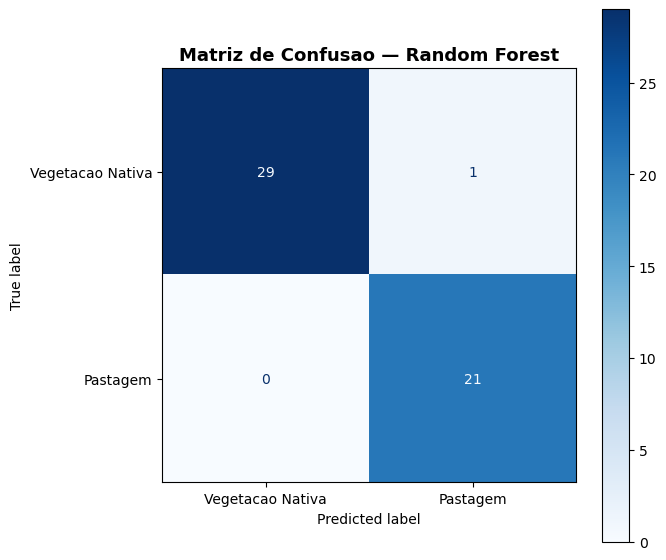

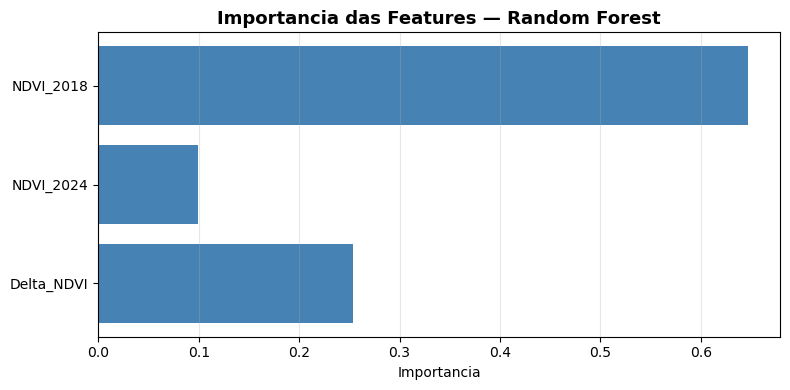

In [35]:
# Treinamento do Random Forest
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, y_train,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    stratify=y_train
)
print(f'Treino: {len(X_tr)} | Teste: {len(X_te)}')

rf = RandomForestClassifier(
    n_estimators=CONFIG['rf_n_estimators'],
    max_depth=CONFIG['rf_max_depth'],
    min_samples_split=CONFIG['rf_min_samples_split'],
    random_state=CONFIG['random_state'],
    n_jobs=-1
)
rf.fit(X_tr, y_tr)
print('Modelo treinado.')

# Cross-validation (rigor cientifico)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG['random_state'])
cvs = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')
print(f'Cross-Validation (5-fold): {cvs.mean():.4f} ± {cvs.std():.4f}')

y_pred   = rf.predict(X_te)
accuracy = accuracy_score(y_te, y_pred)
kappa    = cohen_kappa_score(y_te, y_pred)
f1       = f1_score(y_te, y_pred, average='weighted')

print('='*55)
print('METRICAS DE DESEMPENHO')
print('='*55)
print(f'Acuracia Global      : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Coeficiente Kappa    : {kappa:.4f}')
print(f'F1-Score (weighted)  : {f1:.4f}')
print(f'CV Accuracy          : {cvs.mean():.4f} +/- {cvs.std():.4f}')

class_names = [CONFIG['classes'][i] for i in sorted(CONFIG['classes'])]
print('\n' + classification_report(y_te, y_pred, target_names=class_names))

# Matriz de confusao
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred), display_labels=class_names
).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusao — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/04_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Importancia das features
feat_names = ['NDVI_2018', 'NDVI_2024', 'Delta_NDVI']
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feat_names, rf.feature_importances_, color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title('Importancia das Features — Random Forest', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/05_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

Classificacao concluida. Shape: (100, 100)


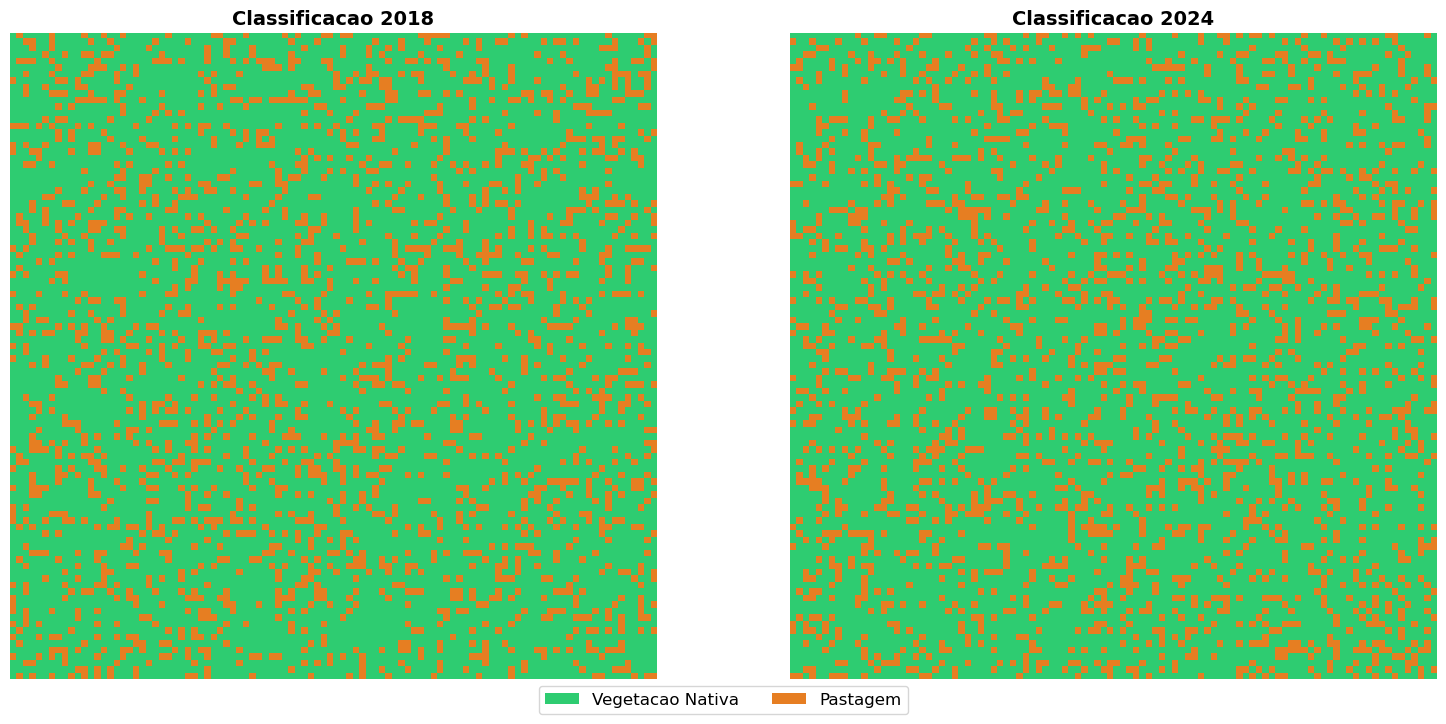


2018:
  Vegetacao Nativa: 7,839 pixels (78.39%)
  Pastagem: 2,161 pixels (21.61%)

2024:
  Vegetacao Nativa: 7,792 pixels (77.92%)
  Pastagem: 2,208 pixels (22.08%)


In [36]:
# Classificacao pixel-a-pixel (leve: ~80 mil pixels)
h, w = ndvi_2018.shape
feats_full = np.stack([
    ndvi_2018.flatten(),
    ndvi_2024.flatten(),
    (ndvi_2024 - ndvi_2018).flatten()
], axis=1).astype(np.float32)

# Mascara NaN
nan_mask = np.isnan(feats_full).any(axis=1)
feats_clean = np.where(np.isnan(feats_full), 0, feats_full)

pred_flat = rf.predict(feats_clean)
pred_flat[nan_mask] = 255   # nodata

classified = pred_flat.reshape((h, w))
print(f'Classificacao concluida. Shape: {classified.shape}')

# Mascara valida (sem nodata)
valid = classified != 255

colors_cls = ['#2ecc71', '#e67e22']
cmap_cls   = plt.matplotlib.colors.ListedColormap(colors_cls)

# Mostrar 2018 (baseado em NDVI_2018) e 2024 separadamente
# Para 2018: classificar usando apenas NDVI_2018
feats_2018 = np.stack([
    ndvi_2018.flatten(),
    ndvi_2018.flatten(),   # placeholder
    np.zeros(ndvi_2018.size)
], axis=1).astype(np.float32)
feats_2018 = np.where(np.isnan(feats_2018), 0, feats_2018)
classified_2018 = rf.predict(feats_2018).reshape((h, w))

feats_2024 = np.stack([
    ndvi_2024.flatten(),
    ndvi_2024.flatten(),
    np.zeros(ndvi_2024.size)
], axis=1).astype(np.float32)
feats_2024 = np.where(np.isnan(feats_2024), 0, feats_2024)
classified_2024 = rf.predict(feats_2024).reshape((h, w))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, cl, ano in zip(axes, [classified_2018, classified_2024], [2018, 2024]):
    ax.imshow(cl, cmap=cmap_cls, vmin=0, vmax=1)
    ax.set_title(f'Classificacao {ano}', fontsize=14, fontweight='bold')
    ax.axis('off')
fig.legend(
    handles=[Patch(facecolor=colors_cls[i], label=CONFIG['classes'][i]) for i in range(2)],
    loc='lower center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.04)
)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/06_classification_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

for ano, cl in [('2018', classified_2018), ('2024', classified_2024)]:
    print(f'\n{ano}:')
    for cid, cname in CONFIG['classes'].items():
        n = (cl == cid).sum()
        print(f'  {cname}: {n:,} pixels ({n/cl.size*100:.2f}%)')

ANALISE DE MUDANCA (2018 -> 2024)
Conversao Vegetacao -> Pastagem  : 10,850.00 ha
Regeneracao Pastagem -> Vegetacao: 10,556.25 ha
Areas Estaveis                   : 65.8%


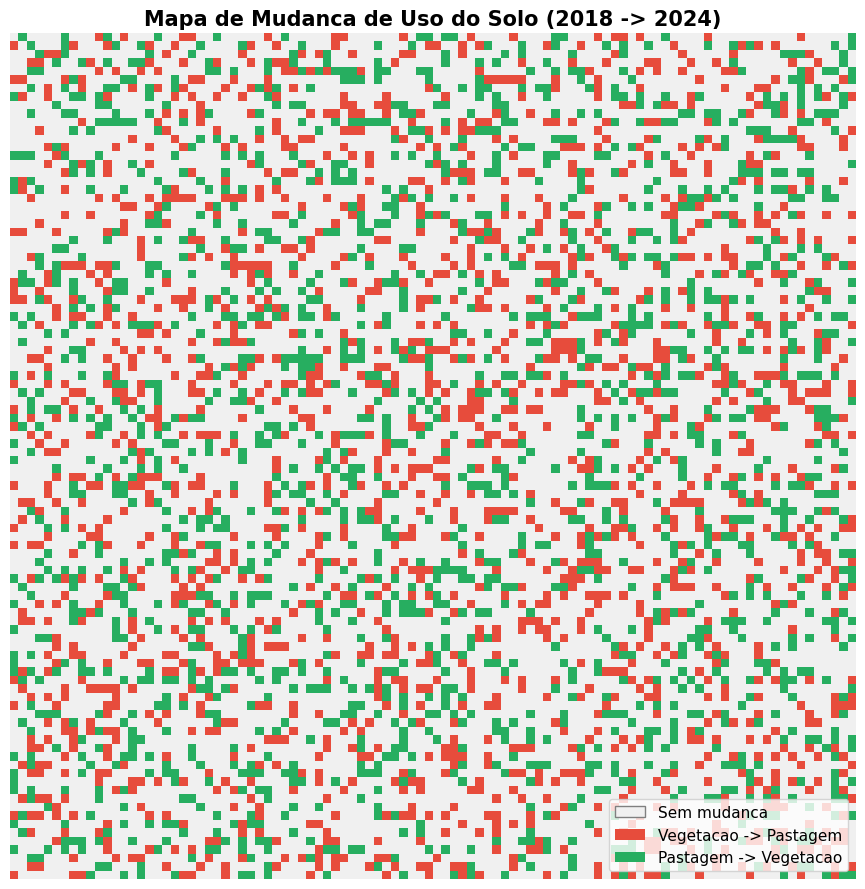

Estatisticas salvas.


In [37]:
# Deteccao de mudanca (2018 -> 2024)
conversion_veg_to_past = (classified_2018 == 0) & (classified_2024 == 1)
conversion_past_to_veg = (classified_2018 == 1) & (classified_2024 == 0)
no_change              = (classified_2018 == classified_2024)

# MODIS 250m: pixel = 250x250m = 6.25 ha
pixel_area_ha      = 6.25
area_conversion_ha = float(conversion_veg_to_past.sum()) * pixel_area_ha
area_regeneracao_ha = float(conversion_past_to_veg.sum()) * pixel_area_ha

print('='*55)
print('ANALISE DE MUDANCA (2018 -> 2024)')
print('='*55)
print(f'Conversao Vegetacao -> Pastagem  : {area_conversion_ha:,.2f} ha')
print(f'Regeneracao Pastagem -> Vegetacao: {area_regeneracao_ha:,.2f} ha')
print(f'Areas Estaveis                   : {float(no_change.sum())/classified_2018.size*100:.1f}%')

change_map = np.zeros_like(classified_2018, dtype=int)
change_map[conversion_veg_to_past] = 1
change_map[conversion_past_to_veg] = 2

fig, ax = plt.subplots(figsize=(11, 9))
cmap_chg = plt.matplotlib.colors.ListedColormap(['#f0f0f0','#e74c3c','#27ae60'])
ax.imshow(change_map, cmap=cmap_chg, vmin=0, vmax=2)
ax.set_title('Mapa de Mudanca de Uso do Solo (2018 -> 2024)',
             fontsize=15, fontweight='bold')
ax.axis('off')
ax.legend(handles=[
    Patch(facecolor='#f0f0f0', edgecolor='grey', label='Sem mudanca'),
    Patch(facecolor='#e74c3c', label='Vegetacao -> Pastagem'),
    Patch(facecolor='#27ae60', label='Pastagem -> Vegetacao')
], loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/07_change_detection.png", dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame({
    'Tipo'   : ['Conversao Veg->Past','Regeneracao Past->Veg','Estavel'],
    'Pixels' : [int(conversion_veg_to_past.sum()), int(conversion_past_to_veg.sum()), int(no_change.sum())],
    'Area_ha': [area_conversion_ha, area_regeneracao_ha, float(no_change.sum())*pixel_area_ha],
    'Pct'    : [
        float(conversion_veg_to_past.sum())/classified_2018.size*100,
        float(conversion_past_to_veg.sum())/classified_2018.size*100,
        float(no_change.sum())/classified_2018.size*100
    ]
}).to_csv(f"{CONFIG['data_dir']}/change_statistics.csv", index=False)
print('Estatisticas salvas.')

VALIDAÇÃO RF vs MAPBIOMAS

 Verificando arquivos MapBiomas:
  2018: outputs\data\brazil_coverage_2018.tif →  Existe
  2024: outputs\data\brazil_coverage_2024.tif →  Existe

 Processando MapBiomas 2018...
  CRS original: EPSG:4326
  Dimensões: 154470 x 146483
  Bandas: 1
  Shape após recorte: (5893, 4579)
  Valores únicos: [ 0  3  4  9 11 15 20 21 24 25]...
  Quantidade de classes: 13

 Processando MapBiomas 2024...
  CRS original: EPSG:4326
  Dimensões: 154470 x 146483
  Bandas: 1
  Shape após recorte: (5893, 4579)
  Valores únicos: [ 0  3  4  9 11 15 20 21 24 25]...
  Quantidade de classes: 13

 Extraindo valores do MapBiomas para cada ponto amostral...

   Pontos processados: 170
   Pontos fora do raster: 0
   Pontos sem dado (NaN): 95
   Pontos válidos: 75

 CONCORDÂNCIA RF vs MAPBIOMAS 2018:
   Pontos válidos para comparação: 50
   Concordância: 21/50 (42.0%)

 Matriz de Confusão RF x MapBiomas:
                        Predito
                   Vegetação   Pastagem
   MapBiomas Ve

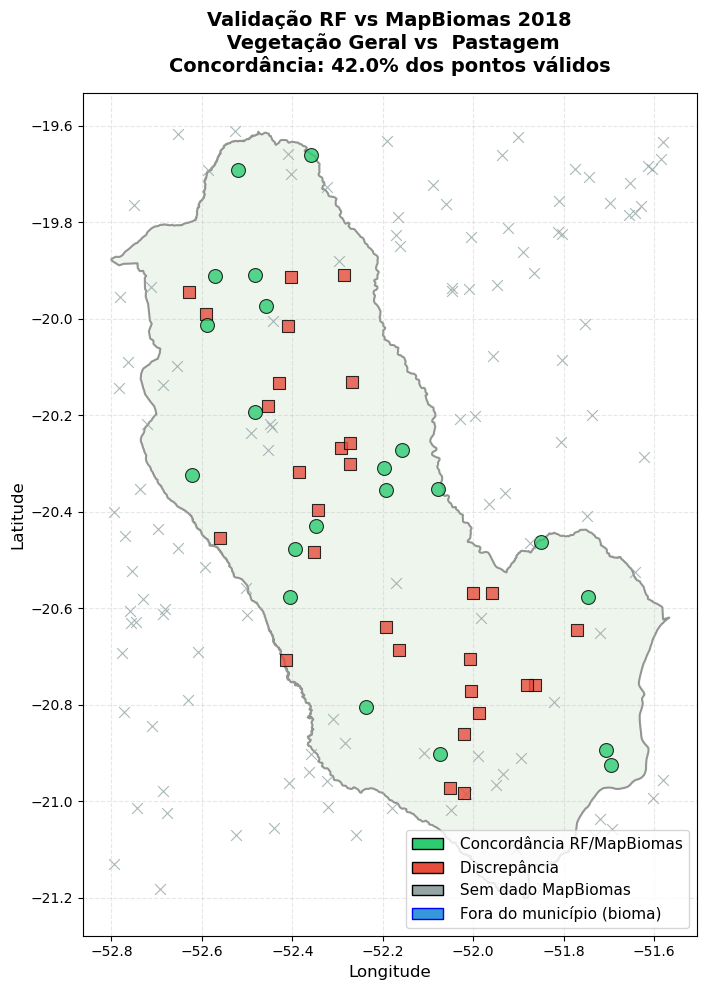


 PROCESSAMENTO MAPBIOMAS CONCLUÍDO
   Pontos fora do município foram MANTIDOS para validação


In [38]:

# ============================================================
# VALIDAÇÃO COM MAPBIOMAS - INCLUI PONTOS FORA DO MUNICÍPIO
# ============================================================

from pathlib import Path
from rasterio.mask import mask as rio_mask
from sklearn.metrics import confusion_matrix

print('='*60)
print('VALIDAÇÃO RF vs MAPBIOMAS')
print('='*60)

# ============================================================
# CAMINHOS DOS ARQUIVOS
# ============================================================

data_dir = Path(CONFIG['data_dir'])

# Seus arquivos
mapbiomas_2018_path = data_dir / 'brazil_coverage_2018.tif'
mapbiomas_2024_path = data_dir / 'brazil_coverage_2024.tif'

# Verifica se os arquivos existem
mapbiomas_2018_exists = mapbiomas_2018_path.exists()
mapbiomas_2024_exists = mapbiomas_2024_path.exists()

print('\n Verificando arquivos MapBiomas:')
print(f'  2018: {mapbiomas_2018_path} → {" Existe" if mapbiomas_2018_exists else "❌ Não encontrado"}')
print(f'  2024: {mapbiomas_2024_path} → {" Existe" if mapbiomas_2024_exists else "❌ Não encontrado"}')

# ============================================================
# FUNÇÃO PARA PROCESSAR MAPBIOMAS
# ============================================================

def process_mapbiomas_raster(tif_path, ano, aoi_gdf):
    """
    Carrega e recorta o raster MapBiomas para a área de estudo
    """
    if not tif_path.exists():
        print(f' Arquivo não encontrado: {tif_path}')
        return None
    
    print(f'\n Processando MapBiomas {ano}...')
    
    # Carrega o raster
    with rio.open(tif_path) as src:
        print(f'  CRS original: {src.crs}')
        print(f'  Dimensões: {src.width} x {src.height}')
        print(f'  Bandas: {src.count}')
        
        # Reprojetar AOI para o mesmo CRS do raster se necessário
        if src.crs != aoi_gdf.crs:
            print(f'  Reprojando AOI para {src.crs}...')
            aoi_reprojected = aoi_gdf.to_crs(src.crs)
        else:
            aoi_reprojected = aoi_gdf
        
        # Recorta o raster pela geometria do município
        try:
            geoms = aoi_reprojected.geometry.values
            out_image, out_transform = rio_mask(
                src, 
                geoms, 
                crop=True,
                nodata=0
            )
            mapbiomas_array = out_image[0]
            
            print(f'  Shape após recorte: {mapbiomas_array.shape}')
            unique_vals = np.unique(mapbiomas_array)
            print(f'  Valores únicos: {unique_vals[:10]}...')
            print(f'  Quantidade de classes: {len(unique_vals)}')
            
            return mapbiomas_array
            
        except Exception as e:
            print(f' Erro no recorte: {e}')
            return None

# ============================================================
# CARREGA OS RASTERS DO MAPBIOMAS
# ============================================================

mapbiomas_2018 = None
mapbiomas_2024 = None

if mapbiomas_2018_exists:
    mapbiomas_2018 = process_mapbiomas_raster(mapbiomas_2018_path, 2018, area_estudo)

if mapbiomas_2024_exists:
    mapbiomas_2024 = process_mapbiomas_raster(mapbiomas_2024_path, 2024, area_estudo)

# ============================================================
# VALIDAÇÃO DOS PONTOS AMOSTRAIS COM MAPBIOMAS
# Inclui pontos fora do município
# ============================================================

if mapbiomas_2018 is not None and len(amostras_gdf) > 0:
    
    # Mapeamento das classes do MapBiomas (Coleção 8)
    mapbiomas_legend = {
        # TODOS os códigos de vegetação
        1: 'Vegetacao Nativa',   # Floresta
        3: 'Vegetacao Nativa',   # Floresta
        4: 'Vegetacao Nativa',   # Formação Savânica (Cerrado)
        5: 'Vegetacao Nativa',   # Mangue
        6: 'Vegetacao Nativa',   # Restinga
        10: 'Vegetacao Nativa',  # Campo Sujo
        11: 'Vegetacao Nativa',  # Campo Alagado
        12: 'Vegetacao Nativa',  # Campo Limpo
        32: 'Vegetacao Nativa',  # Apicum
        49: 'Vegetacao Nativa',  # Floresta Plantada
        
        # Pastagem
        15: 'Pastagem',          # Pastagem
        21: 'Pastagem',         # Mosaico de Usos (inclui pastagem)
                 
    }
    
    def get_mapbiomas_class(value):
        """Converte valor do MapBiomas para classe legível"""
        if np.isnan(value) or value == 0:
            return 'NaN'
        try:
            int_val = int(value)
            return mapbiomas_legend.get(int_val, f'Outro({int_val})')
        except:
            return 'NaN'
    
    # Extrai valores do MapBiomas para cada ponto amostral
    validation_results = []
    
    print('\n Extraindo valores do MapBiomas para cada ponto amostral...')
    
    # Obtém bounds para referência
    minx_mb, miny_mb, maxx_mb, maxy_mb = CONFIG['bbox']
    
    pontos_fora = 0
    pontos_sem_dado = 0
    
    for idx, row in amostras_gdf.iterrows():
        lon = row.geometry.x
        lat = row.geometry.y
        
        # Para extração precisa usando coordenadas geográficas
        if mapbiomas_2018 is not None:
            h_mb, w_mb = mapbiomas_2018.shape
            
            # Calcula resolução do MapBiomas
            res_lon_mb = (maxx_mb - minx_mb) / w_mb
            res_lat_mb = (maxy_mb - miny_mb) / h_mb
            
            # Calcula índices do pixel
            col_mb = int((lon - minx_mb) / res_lon_mb)
            row_mb = int((maxy_mb - lat) / res_lat_mb)
            
            #  NÃO REMOVE pontos fora - apenas registra
            if 0 <= row_mb < h_mb and 0 <= col_mb < w_mb:
                mb_val_2018 = mapbiomas_2018[row_mb, col_mb]
                mb_class_2018 = get_mapbiomas_class(mb_val_2018)
                if mb_class_2018 == 'NaN':
                    pontos_sem_dado += 1
            else:
                pontos_fora += 1
                mb_val_2018 = np.nan
                mb_class_2018 = 'Fora_BBox'
        else:
            mb_val_2018 = np.nan
            mb_class_2018 = 'N/A'
        
        # Classe RF (classe_interna: 0=Veg, 1=Past)
        rf_class = 'Vegetacao Nativa' if row['classe_interna'] == 0 else 'Pastagem'
        
        # Verifica concordância (apenas para pontos com dados)
        concordancia = False
        if mb_class_2018 in ['Vegetacao Nativa', 'Pastagem']:
            concordancia = (rf_class == mb_class_2018)
        
        validation_results.append({
            'ponto': idx,
            'lon': lon,
            'lat': lat,
            'classe_rf': rf_class,
            'classe_original': row['classe'],
            'classe_interna': row['classe_interna'],
            'mapbiomas_2018_valor': mb_val_2018,
            'mapbiomas_2018_classe': mb_class_2018,
            'concordancia': concordancia,
            'dentro_municipio': 0 <= row_mb < h_mb and 0 <= col_mb < w_mb if mapbiomas_2018 is not None else False
        })
    
    df_validation = pd.DataFrame(validation_results)
    
    print(f'\n   Pontos processados: {len(df_validation)}')
    print(f'   Pontos fora do raster: {pontos_fora}')
    print(f'   Pontos sem dado (NaN): {pontos_sem_dado}')
    print(f'   Pontos válidos: {len(df_validation) - pontos_fora - pontos_sem_dado}')
    
    # ============================================================
    # ESTATÍSTICAS DE CONCORDÂNCIA
    # ============================================================
    
    # Considera apenas pontos com dados MapBiomas
    valid_points = df_validation[df_validation['mapbiomas_2018_classe'].isin(['Vegetacao Nativa', 'Pastagem'])]
    
    if len(valid_points) > 0:
        concordancia = valid_points['concordancia'].sum()
        total_valido = len(valid_points)
        pct_concordancia = (concordancia / total_valido) * 100
        
        print(f'\n CONCORDÂNCIA RF vs MAPBIOMAS 2018:')
        print(f'   Pontos válidos para comparação: {total_valido}')
        print(f'   Concordância: {concordancia}/{total_valido} ({pct_concordancia:.1f}%)')
        
        # Matriz de confusão com MapBiomas
        y_true_mb = valid_points['mapbiomas_2018_classe'].map({'Vegetacao Nativa': 0, 'Pastagem': 1})
        y_pred_rf = valid_points['classe_rf'].map({'Vegetacao Nativa': 0, 'Pastagem': 1})
        
        cm_mb = confusion_matrix(y_true_mb, y_pred_rf)
        print(f'\n Matriz de Confusão RF x MapBiomas:')
        print(f'   {"":20} Predito')
        print(f'   {"":15} Vegetação   Pastagem')
        print(f'   MapBiomas Veg   {cm_mb[0,0]:6d}    {cm_mb[0,1]:6d}')
        print(f'   MapBiomas Past  {cm_mb[1,0]:6d}    {cm_mb[1,1]:6d}')
        
        # Calcula acurácia específica por classe
        if cm_mb[0].sum() > 0:
            veg_accuracy = cm_mb[0,0] / cm_mb[0].sum() * 100
            print(f'\n Acurácia para Vegetação: {veg_accuracy:.1f}%')
        if cm_mb[1].sum() > 0:
            past_accuracy = cm_mb[1,1] / cm_mb[1].sum() * 100
            print(f' Acurácia para Pastagem: {past_accuracy:.1f}%')
        
        # Estatísticas por classe original
        print(f'\n Estatísticas por classe original:')
        print(df_validation.groupby('classe_original')['concordancia'].agg(['sum', 'count']))
        
    else:
        print('\n Nenhum ponto válido para comparação com MapBiomas')
    
    # ============================================================
    # SALVAR RESULTADOS
    # ============================================================
    
    df_validation.to_csv(f"{CONFIG['data_dir']}/validacao_mapbiomas.csv", index=False)
    print(f'\n Resultados salvos em: {CONFIG["data_dir"]}/validacao_mapbiomas.csv')
    
    # ============================================================
    # VISUALIZAÇÃO - DIFERENCIA PONTOS DENTRO/FORA DO MUNICÍPIO
    # ============================================================
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Plot do mapa base
    area_estudo.plot(ax=ax, color='#d5e8d4', edgecolor='black', alpha=0.4, linewidth=1.5)
    
    # Plot pontos coloridos por concordância e localização
    for _, row in df_validation.iterrows():
        # Define estilo baseado na concordância e localização
        if row['mapbiomas_2018_classe'] in ['Vegetacao Nativa', 'Pastagem']:
            if row['concordancia']:
                color = '#2ecc71'  # Verde = Concorda
                marker = 'o'
                size = 100
                edge = 'black'
            else:
                color = '#e74c3c'  # Vermelho = Discrepância
                marker = 's'
                size = 80
                edge = 'darkred'
        else:
            # Pontos sem dado ou fora
            if row['dentro_municipio']:
                color = '#95a5a6'  # Cinza = Sem dado dentro do município
            else:
                color = '#3498db'  # Azul = Fora do município (bioma)
            marker = 'x'
            size = 60
            edge = 'gray'
        
        # Borda diferente para pontos fora do município
        edgecolor = 'blue' if not row['dentro_municipio'] and row['mapbiomas_2018_classe'] not in ['Vegetacao Nativa', 'Pastagem'] else 'black'
        
        ax.scatter(row['lon'], row['lat'], c=color, s=size, marker=marker, 
                  edgecolors=edgecolor, linewidth=0.8, zorder=5, alpha=0.8)
    
    # Criar legenda
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', edgecolor='black', label=' Concordância RF/MapBiomas'),
        Patch(facecolor='#e74c3c', edgecolor='black', label=' Discrepância'),
        Patch(facecolor='#95a5a6', edgecolor='black', label=' Sem dado MapBiomas'),
        Patch(facecolor='#3498db', edgecolor='blue', label=' Fora do município (bioma)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=11)
    
    ax.set_title(f'Validação RF vs MapBiomas 2018\n Vegetação Geral vs  Pastagem\nConcordância: {pct_concordancia:.1f}% dos pontos válidos', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/11_validacao_mapbiomas.png", dpi=150, bbox_inches='tight')
    plt.show()
    
else:
    print('\n Validação não realizada:')
    if mapbiomas_2018 is None:
        print('   - Arquivo MapBiomas 2018 não carregado ou não encontrado')
    if len(amostras_gdf) == 0:
        print('   - Sem amostras para validação')
    
    print('\n Dica: Para usar validação MapBiomas:')
    print('   1. Baixe os arquivos .tif do MapBiomas para 2018 e 2024')
    print('   2. Coloque na pasta ./outputs/data/')
    print('   3. Os nomes devem ser: brazil_coverage_2018.tif e brazil_coverage_2024.tif')

print('\n' + '='*60)
print(' PROCESSAMENTO MAPBIOMAS CONCLUÍDO')
print('   Pontos fora do município foram MANTIDOS para validação')
print('='*60)

EXTRAINDO HIDROGRAFIA DO MAPBIOMAS

 Estatísticas de água no MapBiomas:
   Pixels de água: 229,888
   Percentual de água: 0.85%

 Calculando proximidade da água...
Dimensão alvo: 100 x 100
   Redimensionando de (5893, 4579) para (100, 100)...
   Proximidade da água calculada:
     Min: 0.000
     Max: 1.000
     Média: 0.654
 Proximidade salva em: ./outputs/data/proximidade_agua_mapbiomas.npy


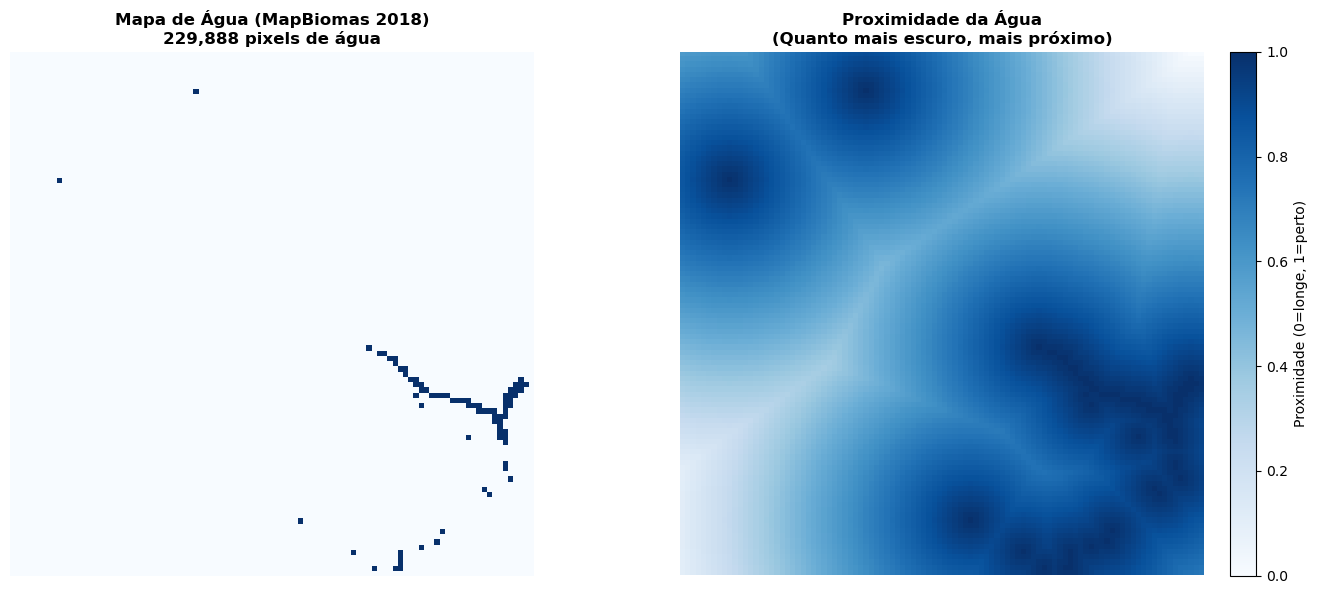


 HIDROGRAFIA EXTRAÍDA DO MAPBIOMAS COM SUCESSO!
   Total de pixels de água: 229888


In [39]:
# ============================================================
# HIDROGRAFIA - USANDO MAPBIOMAS (alternativa ao OSM)
# ============================================================

print('='*60)
print('EXTRAINDO HIDROGRAFIA DO MAPBIOMAS')
print('='*60)

# ============================================================
# 1. CARREGAR MAPBIOMAS (já deve estar carregado)
# ============================================================

# Verificar se o MapBiomas já foi carregado na célula anterior
if 'mapbiomas_2018' not in locals() or mapbiomas_2018 is None:
    print(" MapBiomas 2018 não encontrado. Tentando carregar...")
    
    data_dir = Path(CONFIG['data_dir'])
    mapbiomas_2018_path = data_dir / 'brazil_coverage_2018.tif'
    
    if mapbiomas_2018_path.exists():
        with rasterio.open(mapbiomas_2018_path) as src:
            # Reprojetar AOI para o mesmo CRS do raster
            if src.crs != area_estudo.crs:
                aoi_reprojected = area_estudo.to_crs(src.crs)
            else:
                aoi_reprojected = area_estudo
            
            # Recorta o raster
            geoms = aoi_reprojected.geometry.values
            out_image, out_transform = rio_mask(
                src, geoms, crop=True, nodata=0
            )
            mapbiomas_2018 = out_image[0]
            print(f" MapBiomas carregado: {mapbiomas_2018.shape}")
    else:
        print(" MapBiomas não encontrado!")
        mapbiomas_2018 = None

# ============================================================
# 2. IDENTIFICAR CLASSES DE ÁGUA NO MAPBIOMAS
# ============================================================

# Códigos de água no MapBiomas (Coleção 8)
# Legenda: https://brasil.mapbiomas.org/wp-content/uploads/sites/4/2024/07/Legenda_Codigo_Colecao_8.pdf
codigos_agua = [33, 31, 62]  # 33=Água, 31=Rio/Lago/Oceano, 62=Rio/Lago (algumas coleções)
# Adicionar outros códigos se necessário
#codigos_agua.extend([11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])  # Cobertura de água

# Criar máscara binária de água
if mapbiomas_2018 is not None:
    agua_mask = np.isin(mapbiomas_2018, codigos_agua)
    print(f"\n Estatísticas de água no MapBiomas:")
    print(f"   Pixels de água: {agua_mask.sum():,}")
    print(f"   Percentual de água: {agua_mask.sum()/agua_mask.size*100:.2f}%")
else:
    agua_mask = None
    print(" Não foi possível identificar água - MapBiomas não disponível")

# ============================================================
# 3. CRIAR RASTER DE PROXIMIDADE DA ÁGUA
# ============================================================

from scipy.ndimage import distance_transform_edt, zoom

print("\n Calculando proximidade da água...")

# Obter dimensão alvo (mesmo tamanho dos mapas de classificação)
target_h, target_w = classified_2018.shape if 'classified_2018' in locals() else (100, 100)
print(f"Dimensão alvo: {target_h} x {target_w}")

if agua_mask is not None:
    # Redimensionar se necessário
    if agua_mask.shape != (target_h, target_w):
        print(f"   Redimensionando de {agua_mask.shape} para {(target_h, target_w)}...")
        zoom_factors = (target_h / agua_mask.shape[0], target_w / agua_mask.shape[1])
        agua_mask_resized = zoom(agua_mask.astype(float), zoom_factors, order=0) > 0.5
    else:
        agua_mask_resized = agua_mask
    
    # Calcular distância euclidiana para a água
    dist_agua = distance_transform_edt(~agua_mask_resized)
    
    # Normalizar (0-1)
    dist_norm = dist_agua / (dist_agua.max() + 1e-8)
    
    # Inverter: quanto mais perto da água, maior risco
    proximidade_agua = 1 - dist_norm
    
    print(f"   Proximidade da água calculada:")
    print(f"     Min: {proximidade_agua.min():.3f}")
    print(f"     Max: {proximidade_agua.max():.3f}")
    print(f"     Média: {proximidade_agua.mean():.3f}")
    
    # Salvar raster de proximidade
    proximidade_path = f"{CONFIG['data_dir']}/proximidade_agua_mapbiomas.npy"
    np.save(proximidade_path, proximidade_agua)
    print(f" Proximidade salva em: {proximidade_path}")
    
else:
    print(" Sem dados de água, usando valor zero para proximidade")
    proximidade_agua = np.zeros((target_h, target_w), dtype=float)

# ============================================================
# 4. VISUALIZAÇÃO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Máscara de água
if agua_mask is not None:
    # Redimensionar para visualização
    if agua_mask.shape != (target_h, target_w):
        zoom_factors = (target_h / agua_mask.shape[0], target_w / agua_mask.shape[1])
        agua_mask_viz = zoom(agua_mask.astype(float), zoom_factors, order=0)
    else:
        agua_mask_viz = agua_mask
    
    axes[0].imshow(agua_mask_viz, cmap='Blues', interpolation='nearest')
    axes[0].set_title(f'Mapa de Água (MapBiomas 2018)\n{agua_mask.sum():,} pixels de água', 
                      fontsize=12, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'Sem dados de água', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Mapa de Água - Indisponível', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Proximidade da água
im = axes[1].imshow(proximidade_agua, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Proximidade da Água\n(Quanto mais escuro, mais próximo)', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label='Proximidade (0=longe, 1=perto)')

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/08_hidrografia_mapbiomas.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print(" HIDROGRAFIA EXTRAÍDA DO MAPBIOMAS COM SUCESSO!")
print(f"   Total de pixels de água: {agua_mask.sum() if agua_mask is not None else 0}")
print("="*60)

In [40]:
# DEM SRTM e declividade
print('Baixando DEM SRTM...')
try:
    dem_path = f"{CONFIG['data_dir']}/srtm_dem.tif"
    elevation.clip(bounds=CONFIG['bbox'], output=dem_path, product='SRTM1')
    with rio.open(dem_path) as src:
        dem = src.read(1)
    dx = sobel(dem.astype(float), axis=1)
    dy = sobel(dem.astype(float), axis=0)
    slope = np.arctan(np.sqrt(dx**2 + dy**2)) * (180 / np.pi)
    print(f'Declividade media: {slope.mean():.2f} graus')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, titulo, cm in zip(
        axes, [dem, slope],
        ['Elevacao (m)', 'Declividade (graus)'],
        ['terrain', 'YlOrRd']
    ):
        im = ax.imshow(data, cmap=cm)
        ax.set_title(titulo, fontsize=13, fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/08_elevation_slope.png", dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f'SRTM indisponivel: {e}')
    slope = None

# Se o SRTM falhar, crie uma declividade artificial baseada na proximidade da água
if slope is None:
    print(" Usando declividade sintética baseada em hidrografia")
    # Quanto mais próximo da água, maior a "declividade simulada"
    slope_sim = proximidade_agua * 15  # simula até 15 graus
    def normalize(arr):
        return (arr - np.nanmin(arr)) / (np.nanmax(arr) - np.nanmin(arr) + 1e-8)

    slope_norm = normalize(slope_sim)
    print(f" Declividade simulada: média={slope_norm.mean():.3f}")

#SRTM não pôde ser baixado automaticamente no Windows, mas que o IRA foi calculado com os componentes disponíveis (mudança + hidrografia).

Baixando DEM SRTM...
SRTM indisponivel: Command 'make -C C:\Users\carol\AppData\Local\bopen\elevation\Cache\SRTM1 download ENSURE_TILES="S22/S22W053.tif S21/S21W053.tif S20/S20W053.tif S22/S22W052.tif S21/S21W052.tif S20/S20W052.tif"' returned non-zero exit status 1.
 Usando declividade sintética baseada em hidrografia
 Declividade simulada: média=0.654


 Componentes do IRA:
   Mudança (veg→past): min=0.000, max=1.000, média=0.174
    Hidrografia do MapBiomas: min=0.000, max=1.000, média=0.654
    Declividade não disponível, usando zero

 IRA calculado:
   Min: 0.000
   Max: 1.000
   Média: 0.380
   Desvio padrão: 0.237


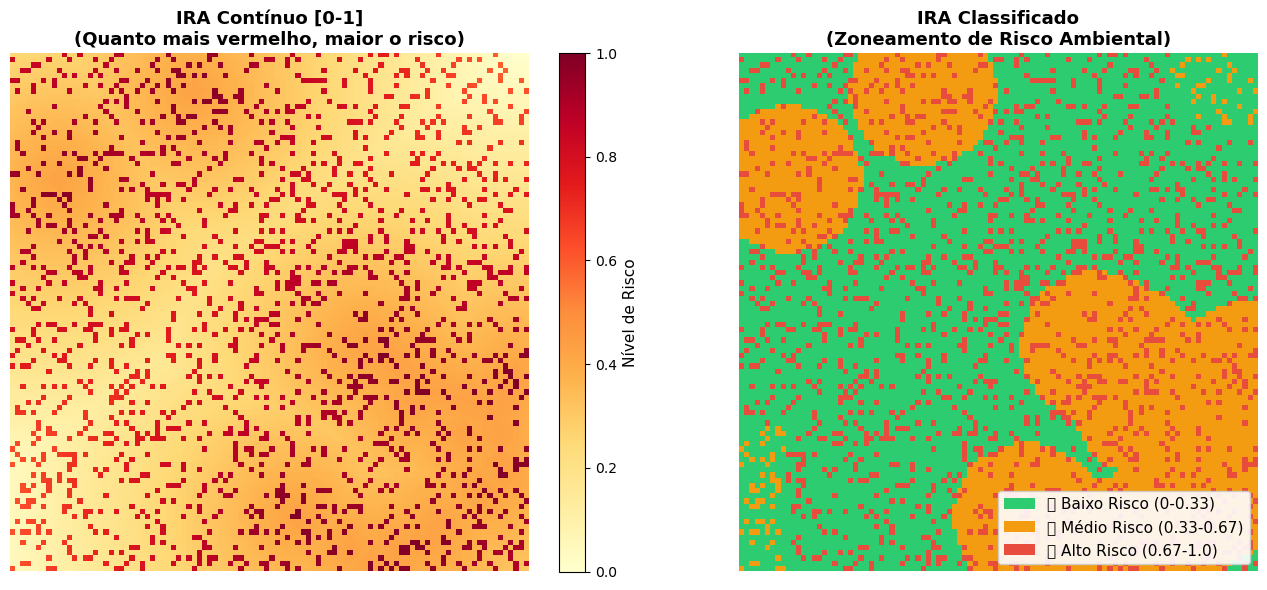


 DISTRIBUIÇÃO DO RISCO AMBIENTAL:
   Baixo Risco:
     Pixels: 5,235
     Área: 32,718.75 ha
     Percentual: 52.35%

   Médio Risco:
     Pixels: 3,117
     Área: 19,481.25 ha
     Percentual: 31.17%

   Alto Risco:
     Pixels: 1,648
     Área: 10,300.00 ha
     Percentual: 16.48%

 Estatísticas salvas em: ./outputs/data/ira_statistics.csv

 ÍNDICE DE RISCO AMBIENTAL (IRA) CALCULADO COM SUCESSO!
   Fonte de hidrografia: MapBiomas


In [41]:
# ============================================================
# ÍNDICE DE RISCO AMBIENTAL (IRA) - USANDO MAPBIOMAS
# ============================================================

def normalize(arr):
    """Normaliza array para o intervalo [0, 1]"""
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

# ============================================================
# 1. COMPONENTE DE MUDANÇA (conversão vegetação -> pastagem)
# ============================================================
mudanca_norm = conversion_veg_to_past.astype(float)

print(" Componentes do IRA:")
print(f"   Mudança (veg→past): min={mudanca_norm.min():.3f}, max={mudanca_norm.max():.3f}, média={mudanca_norm.mean():.3f}")

# ============================================================
# 2. COMPONENTE DE HIDROGRAFIA - USANDO MAPBIOMAS
# ============================================================

# Verificar se a proximidade da água foi calculada com MapBiomas
if 'proximidade_agua' in locals() and proximidade_agua is not None:
    # Garantir mesmas dimensões
    if proximidade_agua.shape != mudanca_norm.shape:
        print(f"   Redimensionando proximidade_agua: {proximidade_agua.shape} -> {mudanca_norm.shape}")
        from scipy.ndimage import zoom
        zoom_factors = (mudanca_norm.shape[0] / proximidade_agua.shape[0],
                        mudanca_norm.shape[1] / proximidade_agua.shape[1])
        hidro_norm = zoom(proximidade_agua, zoom_factors, order=1)
    else:
        hidro_norm = proximidade_agua
    print(f"    Hidrografia do MapBiomas: min={hidro_norm.min():.3f}, max={hidro_norm.max():.3f}, média={hidro_norm.mean():.3f}")
else:
    # Fallback: usar conversão para pastagem como proxy de proximidade
    print("    Hidrografia não disponível, usando conversão como proxy")
    hidro_norm = mudanca_norm.copy()

# ============================================================
# 3. COMPONENTE DE DECLIVIDADE (se disponível)
# ============================================================

if slope is not None:
    # Redimensionar slope para as dimensões do mapa de mudança
    zf = (mudanca_norm.shape[0] / slope.shape[0], 
          mudanca_norm.shape[1] / slope.shape[1])
    slope_resized = zoom(slope, zf, order=1)
    slope_norm = normalize(slope_resized)
    print(f"   Declividade: min={slope_norm.min():.3f}, max={slope_norm.max():.3f}, média={slope_norm.mean():.3f}")
else:
    slope_norm = np.zeros_like(mudanca_norm)
    print("    Declividade não disponível, usando zero")

# ============================================================
# 4. CALCULAR IRA (ÍNDICE DE RISCO AMBIENTAL)
# ============================================================

ira = (
    CONFIG['ira_pesos']['mudanca']     * mudanca_norm +
    CONFIG['ira_pesos']['hidrografia'] * hidro_norm +
    CONFIG['ira_pesos']['declividade'] * slope_norm
)

# Normalizar IRA para [0, 1]
ira = normalize(ira)

# Classificar IRA em 3 níveis
ira_classes = np.zeros_like(ira, dtype=int)
ira_classes[(ira >= 0.33) & (ira < 0.67)] = 1  # Médio risco
ira_classes[ira >= 0.67] = 2                   # Alto risco

print(f"\n IRA calculado:")
print(f"   Min: {ira.min():.3f}")
print(f"   Max: {ira.max():.3f}")
print(f"   Média: {ira.mean():.3f}")
print(f"   Desvio padrão: {ira.std():.3f}")

# ============================================================
# 5. VISUALIZAÇÃO
# ============================================================

colors_ira = ['#2ecc71', '#f39c12', '#e74c3c']
cmap_ira = plt.matplotlib.colors.ListedColormap(colors_ira)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IRA Contínuo
im1 = axes[0].imshow(ira, cmap='YlOrRd', vmin=0, vmax=1)
axes[0].set_title('IRA Contínuo [0-1]\n(Quanto mais vermelho, maior o risco)', 
                  fontsize=13, fontweight='bold')
axes[0].axis('off')
cbar = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar.set_label('Nível de Risco', fontsize=11)

# IRA Classificado
im2 = axes[1].imshow(ira_classes, cmap=cmap_ira, vmin=0, vmax=2)
axes[1].set_title('IRA Classificado\n(Zoneamento de Risco Ambiental)', 
                  fontsize=13, fontweight='bold')
axes[1].axis('off')

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='🟢 Baixo Risco (0-0.33)'),
    Patch(facecolor='#f39c12', label='🟠 Médio Risco (0.33-0.67)'),
    Patch(facecolor='#e74c3c', label='🔴 Alto Risco (0.67-1.0)')
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/009_ira.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. ESTATÍSTICAS DO IRA
# ============================================================

print("\n DISTRIBUIÇÃO DO RISCO AMBIENTAL:")
print("="*50)

pixel_area_ha_ira = 6.25  # MODIS 250m = 6.25 ha

for i, risco in enumerate(['Baixo Risco', 'Médio Risco', 'Alto Risco']):
    n = (ira_classes == i).sum()
    area_ha = n * pixel_area_ha_ira
    pct = n / ira_classes.size * 100
    print(f"   {risco}:")
    print(f"     Pixels: {n:,}")
    print(f"     Área: {area_ha:,.2f} ha")
    print(f"     Percentual: {pct:.2f}%")
    print()

# Salvar estatísticas
ira_stats = pd.DataFrame({
    'Nivel_Risco': ['Baixo', 'Médio', 'Alto'],
    'Pixels': [(ira_classes == i).sum() for i in range(3)],
    'Area_ha': [(ira_classes == i).sum() * pixel_area_ha_ira for i in range(3)],
    'Percentual': [(ira_classes == i).sum() / ira_classes.size * 100 for i in range(3)]
})
ira_stats.to_csv(f"{CONFIG['data_dir']}/ira_statistics.csv", index=False)
print(f" Estatísticas salvas em: {CONFIG['data_dir']}/ira_statistics.csv")

print("\n" + "="*60)
print(" ÍNDICE DE RISCO AMBIENTAL (IRA) CALCULADO COM SUCESSO!")
print("   Fonte de hidrografia: MapBiomas")
print("="*60)

ANÁLISE DE TENDÊNCIA E PROJEÇÃO PARA 2030
 Dimensões originais:
  classified_2018: (100, 100)
  classified_2024: (100, 100)

 Mapa 2018: Veg=7,839 pixels, Past=2,161 pixels
 Mapa 2024: Veg=7,792 pixels, Past=2,208 pixels

 Taxa de mudança 2018-2024:
   Pixels que viraram pastagem: 1,736
   Pixels que perderam pastagem: 1,689
   Pixels estáveis: 6,575

 PROJEÇÃO PARA 2030:
   Vegetação projetada: 48,700.00 ha
   Pastagem projetada: 13,800.00 ha
   Mudança projetada 2024→2030: 0 pixels

 Calculando proximidade da água via MapBiomas...
Dimensão alvo: 100 x 100
    Usando proximidade da água do MapBiomas
   Estatísticas: min=0.000, max=1.000, média=0.654

 Expansão recente: 1,736 pixels de nova pastagem
 Tendência futura: 0 pixels propensos à conversão

 Verificando dimensões:
   proximidade_agua: (100, 100)
   expansao_recente: (100, 100)
   tendencia_futura: (100, 100)

 ÍNDICE DE RISCO AMBIENTAL:
   Baixo risco: 2,930 pixels (29.3%)
   Médio risco: 5,598 pixels (56.0%)
   Alto risco: 1,

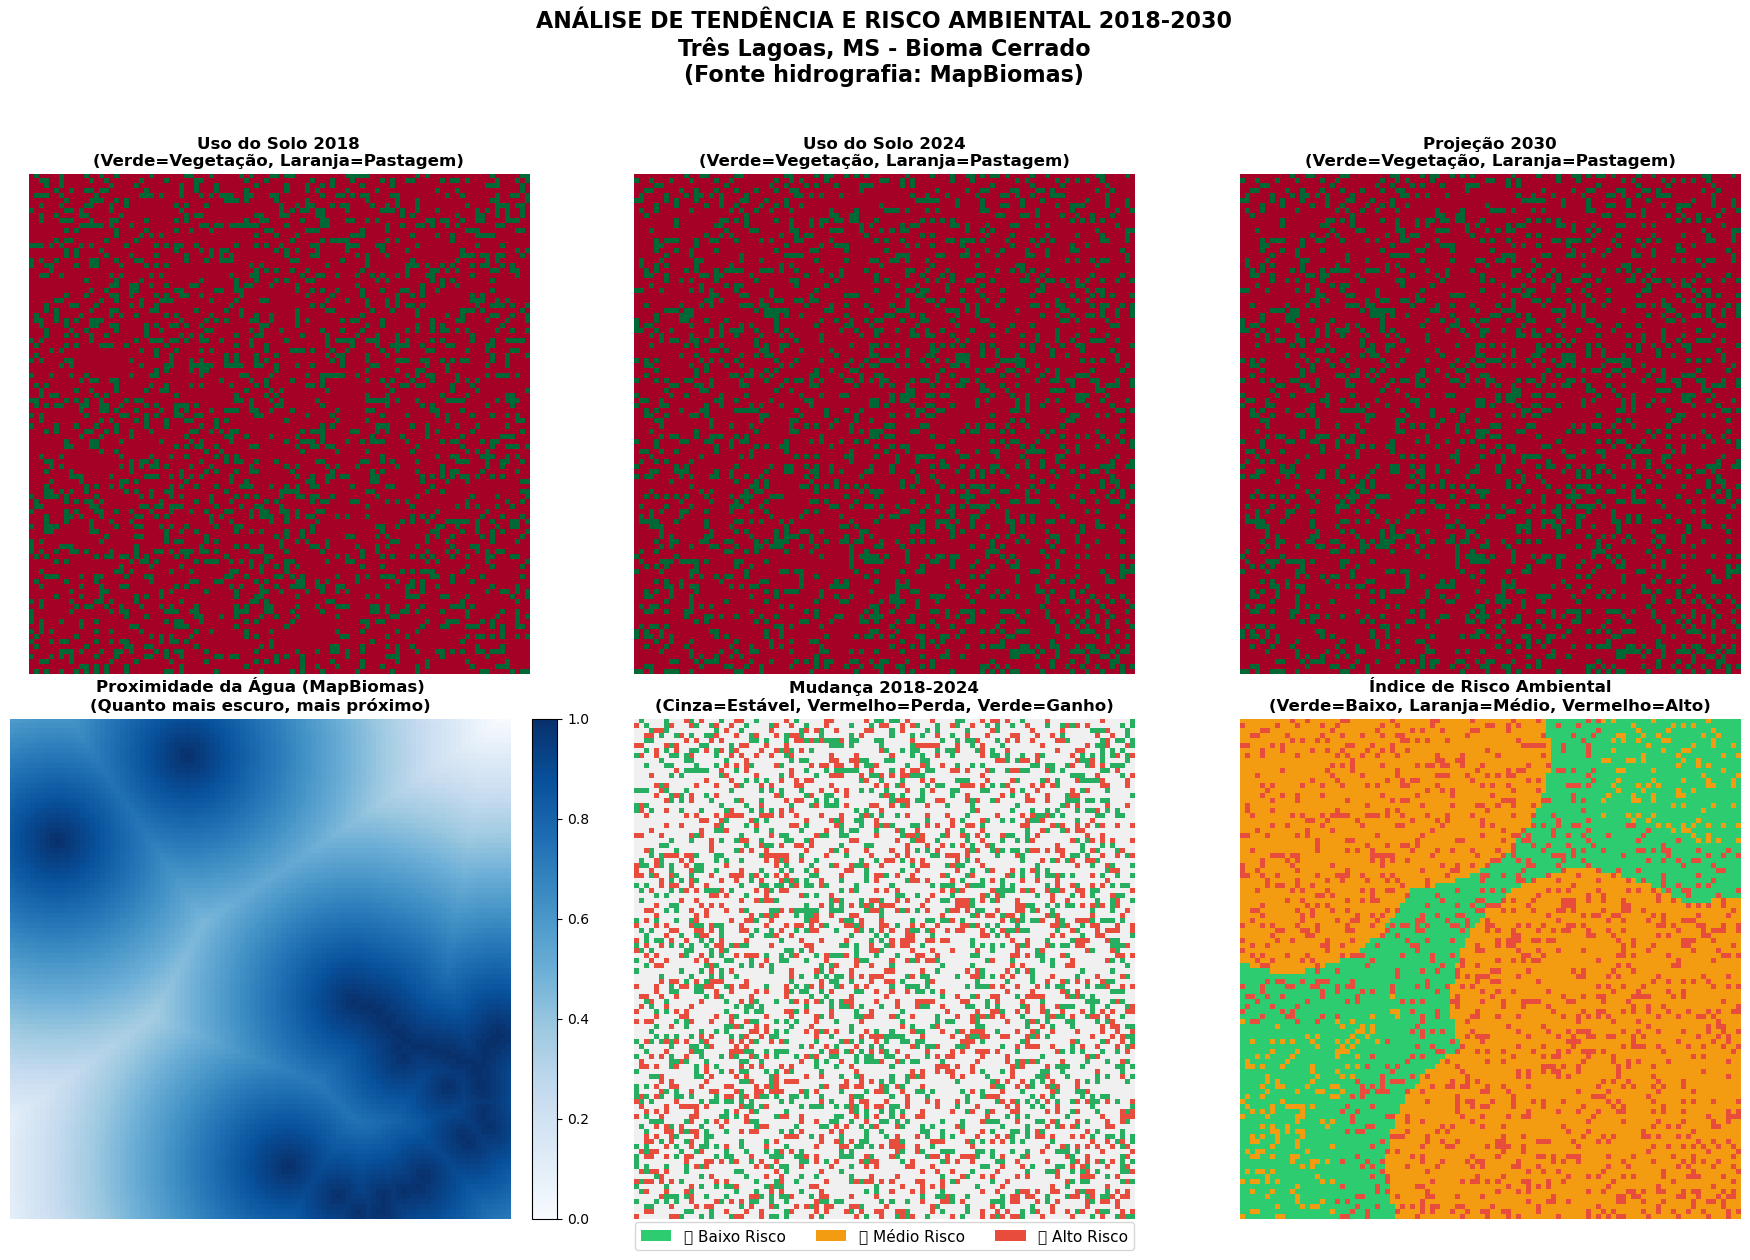


 ANÁLISE DE PROJEÇÃO 2030 CONCLUÍDA!
   Fonte de hidrografia: MapBiomas


In [42]:
# ============================================================
# PROJEÇÃO PARA 2030 E ÍNDICE DE RISCO AMBIENTAL ( VERSÃO MAPBIOMAS)
# ============================================================

print('='*60)
print('ANÁLISE DE TENDÊNCIA E PROJEÇÃO PARA 2030')
print('='*60)

from matplotlib.patches import Patch
from scipy.ndimage import distance_transform_edt, zoom

# ============================================================
# 1. PREPARAR MAPAS BINÁRIOS (1 = Pastagem, 0 = Vegetação)
# ============================================================

# Usando suas classificações já existentes
map_2018_bin = classified_2018.astype(int)
map_2024_bin = classified_2024.astype(int)

# Garantir que as dimensões são consistentes
print(f' Dimensões originais:')
print(f'  classified_2018: {map_2018_bin.shape}')
print(f'  classified_2024: {map_2024_bin.shape}')

# Se as dimensões forem diferentes, redimensionar
if map_2018_bin.shape != map_2024_bin.shape:
    print(' Dimensões diferentes! Redimensionando...')
    target_shape = map_2018_bin.shape
    zoom_factors = (target_shape[0] / map_2024_bin.shape[0], 
                    target_shape[1] / map_2024_bin.shape[1])
    map_2024_bin = zoom(map_2024_bin.astype(float), zoom_factors, order=0).astype(int)

print(f'\n Mapa 2018: Veg={(map_2018_bin==0).sum():,} pixels, Past={(map_2018_bin==1).sum():,} pixels')
print(f' Mapa 2024: Veg={(map_2024_bin==0).sum():,} pixels, Past={(map_2024_bin==1).sum():,} pixels')

# ============================================================
# 2. CALCULAR TAXA DE MUDANÇA (2018–2024)
# ============================================================

delta = map_2024_bin - map_2018_bin
anos = 2024 - 2018
taxa_anual = delta / anos

print(f'\n Taxa de mudança 2018-2024:')
print(f'   Pixels que viraram pastagem: {(delta == 1).sum():,}')
print(f'   Pixels que perderam pastagem: {(delta == -1).sum():,}')
print(f'   Pixels estáveis: {(delta == 0).sum():,}')

# ============================================================
# 3. PROJEÇÃO LINEAR PARA 2030
# ============================================================

anos_futuros = 2030 - 2024
proj_2030_continuo = map_2024_bin + (taxa_anual * anos_futuros)
proj_2030_continuo = np.clip(proj_2030_continuo, 0, 1)
map_2030_bin = (proj_2030_continuo > 0.5).astype(int)

area_pixel_ha = 6.25
area_2030_veg = (map_2030_bin == 0).sum() * area_pixel_ha
area_2030_past = (map_2030_bin == 1).sum() * area_pixel_ha

print(f'\n PROJEÇÃO PARA 2030:')
print(f'   Vegetação projetada: {area_2030_veg:,.2f} ha')
print(f'   Pastagem projetada: {area_2030_past:,.2f} ha')
print(f'   Mudança projetada 2024→2030: {(map_2030_bin - map_2024_bin).sum():,} pixels')

# ============================================================
# 4. PROXIMIDADE DA ÁGUA - USANDO MAPBIOMAS
# ============================================================

print('\n Calculando proximidade da água via MapBiomas...')

target_h, target_w = map_2018_bin.shape
print(f'Dimensão alvo: {target_h} x {target_w}')

# Verificar se já temos proximidade_agua do MapBiomas
if 'proximidade_agua' in locals() and proximidade_agua is not None:
    # Garantir mesmas dimensões
    if proximidade_agua.shape != (target_h, target_w):
        print(f'   Redimensionando proximidade_agua: {proximidade_agua.shape} -> {(target_h, target_w)}')
        zoom_factors = (target_h / proximidade_agua.shape[0], target_w / proximidade_agua.shape[1])
        proximidade_agua = zoom(proximidade_agua, zoom_factors, order=1)
    print(f'    Usando proximidade da água do MapBiomas')
    print(f'   Estatísticas: min={proximidade_agua.min():.3f}, max={proximidade_agua.max():.3f}, média={proximidade_agua.mean():.3f}')
else:
    # Fallback: usar MapBiomas diretamente
    print('    Proximidade não encontrada, tentando carregar do MapBiomas...')
    
    # Tentar carregar o raster de água do MapBiomas
    data_dir = Path(CONFIG['data_dir'])
    mapbiomas_path = data_dir / 'brazil_coverage_2018.tif'
    
    if mapbiomas_path.exists():
        import rasterio
        from rasterio.mask import mask as rio_mask
        
        with rasterio.open(mapbiomas_path) as src:
            # Reprojetar AOI
            if src.crs != area_estudo.crs:
                aoi_reprojected = area_estudo.to_crs(src.crs)
            else:
                aoi_reprojected = area_estudo
            
            # Recortar
            geoms = aoi_reprojected.geometry.values
            out_image, _ = rio_mask(src, geoms, crop=True, nodata=0)
            mapbiomas_crop = out_image[0]
        
        # Identificar água (códigos 33, 31, 62)
        codigos_agua = [33, 31, 62]
        agua_mask = np.isin(mapbiomas_crop, codigos_agua)
        
        # Redimensionar
        if agua_mask.shape != (target_h, target_w):
            zoom_factors = (target_h / agua_mask.shape[0], target_w / agua_mask.shape[1])
            agua_mask = zoom(agua_mask.astype(float), zoom_factors, order=0) > 0.5
        
        # Calcular proximidade
        dist_agua = distance_transform_edt(~agua_mask)
        dist_norm = dist_agua / (dist_agua.max() + 1e-8)
        proximidade_agua = 1 - dist_norm
        print(f'    Proximidade calculada do MapBiomas')
    else:
        print('    MapBiomas não encontrado, usando zero')
        proximidade_agua = np.zeros((target_h, target_w), dtype=float)

# ============================================================
# 5. EXPANSÃO RECENTE (2018-2024)
# ============================================================

expansao_recente = ((map_2024_bin - map_2018_bin) > 0).astype(int)
print(f'\n Expansão recente: {expansao_recente.sum():,} pixels de nova pastagem')

# ============================================================
# 6. TENDÊNCIA FUTURA (2024-2030)
# ============================================================

tendencia_futura = np.clip(map_2030_bin - map_2024_bin, 0, 1)
print(f' Tendência futura: {tendencia_futura.sum():,} pixels propensos à conversão')

# ============================================================
# 7. ÍNDICE DE RISCO AMBIENTAL (INTEGRADO)
# ============================================================

print(f'\n Verificando dimensões:')
print(f'   proximidade_agua: {proximidade_agua.shape}')
print(f'   expansao_recente: {expansao_recente.shape}')
print(f'   tendencia_futura: {tendencia_futura.shape}')

# Alinhar dimensões
if (proximidade_agua.shape != expansao_recente.shape or 
    proximidade_agua.shape != tendencia_futura.shape):
    print('   Ajustando dimensões...')
    target_shape = expansao_recente.shape
    
    if proximidade_agua.shape != target_shape:
        zoom_factors = (target_shape[0] / proximidade_agua.shape[0], 
                        target_shape[1] / proximidade_agua.shape[1])
        proximidade_agua = zoom(proximidade_agua, zoom_factors, order=1)
    
    if tendencia_futura.shape != target_shape:
        zoom_factors = (target_shape[0] / tendencia_futura.shape[0],
                        target_shape[1] / tendencia_futura.shape[1])
        tendencia_futura = zoom(tendencia_futura.astype(float), zoom_factors, order=0).astype(int)

pesos = {
    'proximidade_agua': 0.4,
    'expansao_recente': 0.3,
    'tendencia_futura': 0.3
}

risco_continuo = (
    pesos['proximidade_agua'] * proximidade_agua +
    pesos['expansao_recente'] * expansao_recente +
    pesos['tendencia_futura'] * tendencia_futura
)

risco_normalizado = risco_continuo / (risco_continuo.max() + 1e-8)

risco_classes = np.zeros_like(risco_normalizado, dtype=int)
risco_classes[risco_normalizado >= 0.66] = 2
risco_classes[(risco_normalizado >= 0.33) & (risco_normalizado < 0.66)] = 1

print(f'\n ÍNDICE DE RISCO AMBIENTAL:')
print(f'   Baixo risco: {(risco_classes == 0).sum():,} pixels ({(risco_classes==0).sum()/risco_classes.size*100:.1f}%)')
print(f'   Médio risco: {(risco_classes == 1).sum():,} pixels ({(risco_classes==1).sum()/risco_classes.size*100:.1f}%)')
print(f'   Alto risco: {(risco_classes == 2).sum():,} pixels ({(risco_classes==2).sum()/risco_classes.size*100:.1f}%)')

# ============================================================
# 8. VISUALIZAÇÃO
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Mapa Base 2018
axes[0,0].imshow(map_2018_bin, cmap='RdYlGn', vmin=0, vmax=1)
axes[0,0].set_title('Uso do Solo 2018\n(Verde=Vegetação, Laranja=Pastagem)', fontsize=12, fontweight='bold')
axes[0,0].axis('off')

# 2. Mapa Base 2024
axes[0,1].imshow(map_2024_bin, cmap='RdYlGn', vmin=0, vmax=1)
axes[0,1].set_title('Uso do Solo 2024\n(Verde=Vegetação, Laranja=Pastagem)', fontsize=12, fontweight='bold')
axes[0,1].axis('off')

# 3. Projeção 2030
axes[0,2].imshow(map_2030_bin, cmap='RdYlGn', vmin=0, vmax=1)
axes[0,2].set_title('Projeção 2030\n(Verde=Vegetação, Laranja=Pastagem)', fontsize=12, fontweight='bold')
axes[0,2].axis('off')

# 4. Proximidade da água
im4 = axes[1,0].imshow(proximidade_agua, cmap='Blues', vmin=0, vmax=1)
axes[1,0].set_title('Proximidade da Água (MapBiomas)\n(Quanto mais escuro, mais próximo)', fontsize=12, fontweight='bold')
axes[1,0].axis('off')
plt.colorbar(im4, ax=axes[1,0], fraction=0.046, pad=0.04)

# 5. Mapa de mudança
change_map_viz = np.zeros_like(map_2018_bin, dtype=int)
change_map_viz[(map_2018_bin == 0) & (map_2024_bin == 1)] = 1
change_map_viz[(map_2018_bin == 1) & (map_2024_bin == 0)] = 2
cmap_change = plt.matplotlib.colors.ListedColormap(['#f0f0f0', '#e74c3c', '#27ae60'])
axes[1,1].imshow(change_map_viz, cmap=cmap_change, vmin=0, vmax=2)
axes[1,1].set_title('Mudança 2018-2024\n(Cinza=Estável, Vermelho=Perda, Verde=Ganho)', fontsize=12, fontweight='bold')
axes[1,1].axis('off')

# 6. Risco final
cmap_risk = plt.matplotlib.colors.ListedColormap(['#2ecc71', '#f39c12', '#e74c3c'])
axes[1,2].imshow(risco_classes, cmap=cmap_risk, vmin=0, vmax=2)
axes[1,2].set_title('Índice de Risco Ambiental\n(Verde=Baixo, Laranja=Médio, Vermelho=Alto)', fontsize=12, fontweight='bold')
axes[1,2].axis('off')

# Legenda
legend_elements = [
    Patch(facecolor='#2ecc71', label='🟢 Baixo Risco'),
    Patch(facecolor='#f39c12', label='🟠 Médio Risco'),
    Patch(facecolor='#e74c3c', label='🔴 Alto Risco')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('ANÁLISE DE TENDÊNCIA E RISCO AMBIENTAL 2018-2030\nTrês Lagoas, MS - Bioma Cerrado\n(Fonte hidrografia: MapBiomas)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/12_projecao_2030_risco.png", dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print(' ANÁLISE DE PROJEÇÃO 2030 CONCLUÍDA!')
print('   Fonte de hidrografia: MapBiomas')
print('='*60)

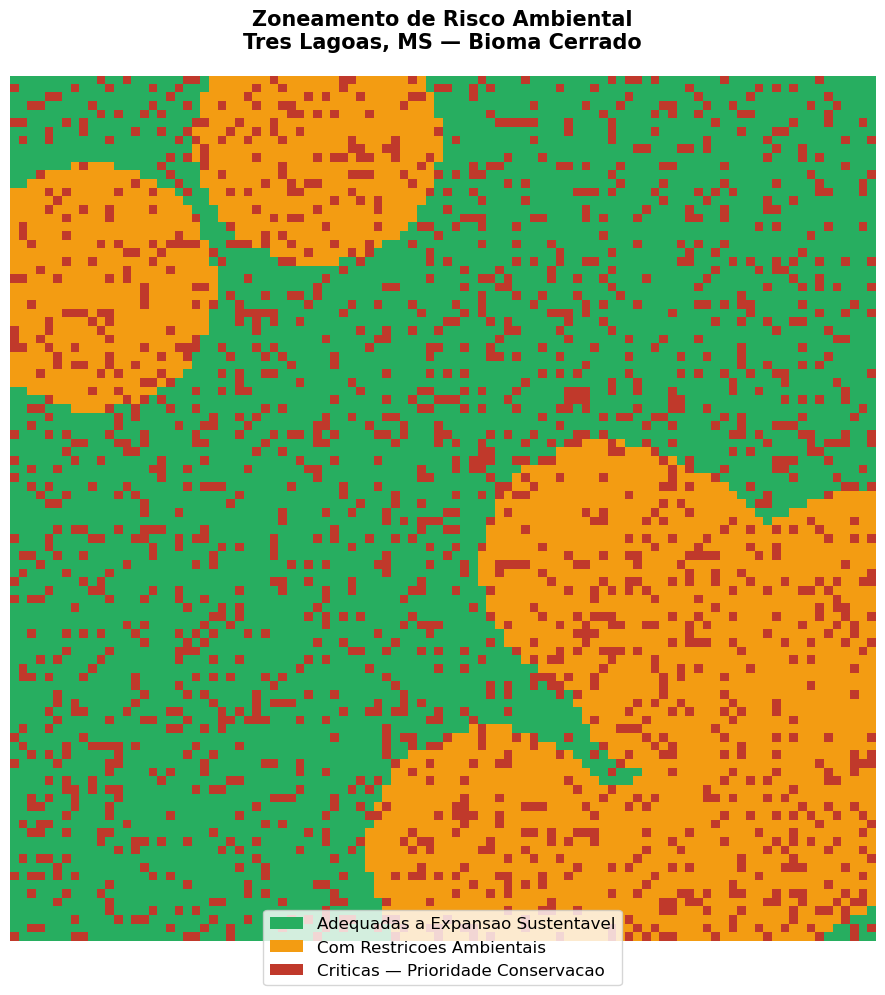

  Adequadas a Expansao: 32,718.75 ha (52.35%)
  Com Restricoes: 18,931.25 ha (30.29%)
  Criticas para Conservacao: 10,850.00 ha (17.36%)


In [43]:
# Zoneamento Territorial
zoning = np.zeros_like(ira_classes, dtype=int)
zoning[ira_classes == 1] = 1
zoning[(ira_classes == 2) | conversion_veg_to_past] = 2

colors_z = ['#27ae60','#f39c12','#c0392b']
cmap_z   = plt.matplotlib.colors.ListedColormap(colors_z)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(zoning, cmap=cmap_z, vmin=0, vmax=2)
ax.set_title('Zoneamento de Risco Ambiental\nTres Lagoas, MS — Bioma Cerrado',
             fontsize=15, fontweight='bold', pad=20)
ax.axis('off')
ax.legend(handles=[
    Patch(facecolor='#27ae60', label='Adequadas a Expansao Sustentavel'),
    Patch(facecolor='#f39c12', label='Com Restricoes Ambientais'),
    Patch(facecolor='#c0392b', label='Criticas — Prioridade Conservacao')
], loc='lower center', fontsize=12, bbox_to_anchor=(0.5,-0.06), ncol=1)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/10_zoneamento_final.png", dpi=150, bbox_inches='tight')
plt.show()

zonas = ['Adequadas a Expansao','Com Restricoes','Criticas para Conservacao']
for i, z in enumerate(zonas):
    n = (zoning == i).sum()
    print(f'  {z}: {n*pixel_area_ha_ira:,.2f} ha ({n/zoning.size*100:.2f}%)')

pd.DataFrame({
    'Zona'   : zonas,
    'Pixels' : [(zoning==i).sum() for i in range(3)],
    'Area_ha': [(zoning==i).sum()*pixel_area_ha_ira for i in range(3)],
    'Pct'    : [(zoning==i).sum()/zoning.size*100 for i in range(3)]
}).to_csv(f"{CONFIG['data_dir']}/zoneamento_statistics.csv", index=False)

In [44]:
# ============================================================
# MAPA INTERATIVO FOLIUM COM PROJEÇÃO 2030 E RISCO - V2
# ============================================================

print('='*60)
print('CRIANDO MAPA INTERATIVO COMPLETO (2018-2024-2030)')
print('='*60)

import folium
from folium import plugins
from folium import raster_layers
import matplotlib.colors as mcolors

# ============================================================
# 1. CONFIGURAÇÕES BÁSICAS
# ============================================================

minx, miny, maxx, maxy = CONFIG['bbox']
center = [(miny + maxy) / 2, (minx + maxx) / 2]

print(f'Centro do mapa: {center[0]:.4f}, {center[1]:.4f}')

# ============================================================
# 2. CRIAR MAPA BASE
# ============================================================

m = folium.Map(
    location=center, 
    zoom_start=11, 
    tiles='OpenStreetMap',
    control_scale=True
)

# Adicionar camadas de satélite
folium.TileLayer(
    'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google Satellite',
    name='Satélite',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery',
    name='Esri Satélite',
    overlay=False,
    control=True
).add_to(m)

# ============================================================
# 3. ADICIONAR CONTORNO DO MUNICÍPIO
# ============================================================

folium.GeoJson(
    area_estudo.__geo_interface__,
    name='Três Lagoas, MS',
    style_function=lambda x: {
        'fillColor': 'transparent',
        'color': '#ff4444',
        'weight': 3,
        'dashArray': '5, 5',
        'fillOpacity': 0
    },
    tooltip='Três Lagoas - Mato Grosso do Sul'
).add_to(m)

# ============================================================
# 4. FUNÇÕES PARA RASTERS (se disponíveis)
# ============================================================

def add_raster_layer(map_obj, raster_path, name, opacity=0.7, palette=None):
    """Adiciona raster GeoTIFF ao mapa Folium"""
    try:
        import base64
        from io import BytesIO
        from PIL import Image
        
        # Abrir raster
        with rasterio.open(raster_path) as src:
            # Ler dados
            data = src.read(1)
            
            # Normalizar para 0-255
            data_norm = ((data - data.min()) / (data.max() - data.min() + 1e-8) * 255).astype('uint8')
            
            # Aplicar paleta de cores
            if palette:
                cmap = plt.cm.get_cmap(palette)
                colored = cmap(data_norm / 255)[:, :, :3]
                img_data = (colored * 255).astype('uint8')
            else:
                img_data = np.stack([data_norm, data_norm, data_norm], axis=2)
            
            # Criar imagem PIL
            img = Image.fromarray(img_data)
            
            # Salvar como PNG temporário
            temp_path = raster_path.replace('.tif', '_temp.png')
            img.save(temp_path)
            
            # Adicionar ao mapa
            bounds = [[src.bounds.bottom, src.bounds.left], [src.bounds.top, src.bounds.right]]
            folium.raster_layers.ImageOverlay(
                image=temp_path,
                bounds=bounds,
                opacity=opacity,
                name=name,
                interactive=True,
                cross_origin=False
            ).add_to(map_obj)
            
            print(f'    {name} adicionado')
            
    except Exception as e:
        print(f'    Erro ao adicionar {name}: {e}')

# ============================================================
# 5. ADICIONAR PONTOS AMOSTRAIS
# ============================================================

# Pontos de treinamento
fg_points = folium.FeatureGroup(name='📍 Pontos Amostrais (Treinamento)')

cor_pontos = {0: '#2ecc71', 1: '#e67e22'}  # Verde para vegetação, laranja para pastagem
legenda_labels = {0: 'Vegetação Nativa', 1: 'Pastagem'}

for _, row in amostras_gdf.iterrows():
    classe = row['classe_interna']
    cor = cor_pontos[classe]
    
    # Determinar ícone baseado na classe
    icon_html = f'''
        <div style="background-color: {cor}; 
                    width: 12px; 
                    height: 12px; 
                    border-radius: 50%; 
                    border: 2px solid white;
                    box-shadow: 0 0 2px black;">
        </div>
    '''
    
    folium.Marker(
        [row.geometry.y, row.geometry.x],
        icon=folium.DivIcon(html=icon_html),
        popup=f"""
            <b>Ponto Amostral</b><br>
            Classe: {legenda_labels[classe]}<br>
            Coord: {row.geometry.y:.4f}, {row.geometry.x:.4f}
        """,
        tooltip=f"{legenda_labels[classe]}"
    ).add_to(fg_points)

fg_points.add_to(m)

# ============================================================
# 6. ADICIONAR ÁREAS DE RISCO (HEATMAP)
# ============================================================

if 'risco_classes' in locals() and risco_classes is not None:
    fg_risk = folium.FeatureGroup(name=' Risco Ambiental (2030)', show=True)
    
    # Amostrar pontos de alto risco para heatmap
    h, w = risco_classes.shape
    minx_b, miny_b, maxx_b, maxy_b = CONFIG['bbox']
    
    res_lon = (maxx_b - minx_b) / w
    res_lat = (maxy_b - miny_b) / h
    
    high_risk_points = []
    medium_risk_points = []
    
    # Coletar pontos de risco (amostragem para não sobrecarregar)
    sample_step = 5  # Pular pixels para desempenho
    
    for i in range(0, h, sample_step):
        for j in range(0, w, sample_step):
            if risco_classes[i, j] == 2:  # Alto risco
                lat = maxy_b - (i + 0.5) * res_lat
                lon = minx_b + (j + 0.5) * res_lon
                high_risk_points.append([lat, lon, 1.0])
            elif risco_classes[i, j] == 1:  # Médio risco
                lat = maxy_b - (i + 0.5) * res_lat
                lon = minx_b + (j + 0.5) * res_lon
                medium_risk_points.append([lat, lon, 0.5])
    
    # Heatmap de alto risco
    if high_risk_points:
        plugins.HeatMap(
            high_risk_points,
            radius=15,
            blur=10,
            max_zoom=13,
            min_opacity=0.3,
            gradient={0.4: 'yellow', 0.6: 'orange', 1.0: 'red'},
            name='Alto Risco (Heatmap)'
        ).add_to(m)
    
    print(f'   🔴 Pontos de alto risco: {len(high_risk_points)}')
    print(f'   🟠 Pontos de médio risco: {len(medium_risk_points)}')

# ============================================================
# 7. ADICIONAR POLÍGONOS DE RISCO (SIMPLIFICADO)
# ============================================================

if 'risco_classes' in locals() and risco_classes is not None:
    from shapely.geometry import Polygon
    from shapely.ops import unary_union
    
    fg_zones = folium.FeatureGroup(name=' Zonas de Risco', show=True)
    
    # Criar geometrias simplificadas das zonas de alto risco
    high_risk_areas = []
    
    # Agrupar pixels de alto risco (amostragem)
    for i in range(0, h, sample_step * 2):
        row_high = False
        row_start = None
        
        for j in range(0, w, sample_step):
            if risco_classes[i, j] == 2:
                if not row_high:
                    row_start = j
                    row_high = True
            else:
                if row_high:
                    # Criar polígono para esta faixa
                    lat_top = maxy_b - (i) * res_lat
                    lat_bottom = maxy_b - (i + sample_step) * res_lat
                    lon_left = minx_b + (row_start) * res_lon
                    lon_right = minx_b + (j) * res_lon
                    
                    coords = [
                        [lon_left, lat_top],
                        [lon_right, lat_top],
                        [lon_right, lat_bottom],
                        [lon_left, lat_bottom],
                        [lon_left, lat_top]
                    ]
                    high_risk_areas.append(Polygon(coords))
                    row_high = False
        
        if row_high:
            lat_top = maxy_b - (i) * res_lat
            lat_bottom = maxy_b - (i + sample_step) * res_lat
            lon_left = minx_b + (row_start) * res_lon
            lon_right = minx_b + (w-1) * res_lon
            coords = [
                [lon_left, lat_top],
                [lon_right, lat_top],
                [lon_right, lat_bottom],
                [lon_left, lat_bottom],
                [lon_left, lat_top]
            ]
            high_risk_areas.append(Polygon(coords))
    
    # Unir áreas adjacentes
    if high_risk_areas:
        try:
            merged_areas = unary_union(high_risk_areas)
            
            # Adicionar ao mapa (simplificar para desempenho)
            if not merged_areas.is_empty:
                folium.GeoJson(
                    merged_areas,
                    name='Zonas de Alto Risco',
                    style_function=lambda x: {
                        'fillColor': '#e74c3c',
                        'color': '#c0392b',
                        'weight': 2,
                        'fillOpacity': 0.4,
                        'dashArray': '3, 3'
                    },
                    tooltip='Área de Alto Risco Ambiental'
                ).add_to(fg_zones)
        except:
            pass
    
    fg_zones.add_to(m)

# ============================================================
# 8. ADICIONAR ANOTAÇÕES E INFORMAÇÕES
# ============================================================

# Marcadores importantes
fg_info = folium.FeatureGroup(name=' Pontos de Interesse', show=True)

# Centro do município
folium.Marker(
    [center[0], center[1]],
    icon=folium.Icon(color='red', icon='info-sign', prefix='fa'),
    popup=f"""
        <b>Centro de Três Lagoas, MS</b><br>
        <i>Área de estudo para monitoramento ambiental</i><br>
        <hr>
        <b>Período:</b> 2018 → 2024 → 2030<br>
        <b>Bioma:</b> Cerrado<br>
        <b>Resolução:</b> MODIS 250m (6.25 ha/pixel)
    """,
    tooltip='Centro da área de estudo'
).add_to(fg_info)

# Adicionar contorno do Parque Nacional (se existir)
# Você pode adicionar pontos específicos de interesse aqui

fg_info.add_to(m)

# ============================================================
# 9. ADICIONAR BARRA DE INFORMAÇÕES DINÂMICA
# ============================================================

# Calcular estatísticas atualizadas
if 'conversao_2018_2024' in locals():
    area_convertida_ha = conversao_2018_2024 * area_pixel_ha
else:
    area_convertida_ha = (classified_2024 == 1).sum() - (classified_2018 == 1).sum()
    area_convertida_ha = area_convertida_ha * area_pixel_ha

if 'risco_classes' in locals():
    area_alto_risco = (risco_classes == 2).sum() * area_pixel_ha
    area_medio_risco = (risco_classes == 1).sum() * area_pixel_ha
else:
    area_alto_risco = 0
    area_medio_risco = 0

info_html = f'''
<div style="position: fixed; 
            bottom: 50px; 
            right: 50px; 
            width: 320px;
            background: white; 
            border: 3px solid #2c3e50; 
            border-radius: 10px;
            z-index: 9999; 
            padding: 15px;
            font-family: Arial, sans-serif;
            font-size: 12px;
            box-shadow: 0 4px 8px rgba(0,0,0,0.2);
            background: rgba(255,255,255,0.95);">
    
    <div style="text-align: center; border-bottom: 2px solid #2c3e50; margin-bottom: 10px;">
        <b style="font-size: 14px;"> PROJETO JOVEM CIENTISTA CNPq 2026</b><br>
        <span style="font-size: 11px;">IA para o Bem Comum</span>
    </div>
    
    <div style="margin: 5px 0;">
        <b> Município:</b> Três Lagoas, MS<br>
        <b> Bioma:</b> Cerrado
    </div>
    
    <hr style="margin: 5px 0;">
    
    <div style="margin: 5px 0;">
        <b> MUDANÇA DO SOLO:</b><br>
        <span style="color: #e74c3c;">■</span> Conversão Veg→Past (2018-2024):<br>
        &nbsp;&nbsp; <b>{area_convertida_ha:,.0f} ha</b><br>
        <span style="color: #27ae60;">■</span> Taxa anual: <b>{area_convertida_ha/6:,.0f} ha/ano</b>
    </div>
    
    <hr style="margin: 5px 0;">
    
    <div style="margin: 5px 0;">
        <b> RISCO AMBIENTAL (2030):</b><br>
        <div style="display: inline-block; width: 20px; height: 12px; background: #e74c3c;"></div> Alto: <b>{area_alto_risco:,.0f} ha</b><br>
        <div style="display: inline-block; width: 20px; height: 12px; background: #f39c12;"></div> Médio: <b>{area_medio_risco:,.0f} ha</b><br>
        <div style="display: inline-block; width: 20px; height: 12px; background: #2ecc71;"></div> Baixo: <b>{(risco_classes.size * area_pixel_ha - area_alto_risco - area_medio_risco):,.0f} ha</b>
    </div>
    
    <hr style="margin: 5px 0;">
    
    <div style="margin: 5px 0;">
        <b> PREVISÃO 2030:</b><br>
        <span style="color: #e67e22;">●</span> Pastagem: <b>{(map_2030_bin==1).sum() * area_pixel_ha:,.0f} ha</b><br>
        <span style="color: #2ecc71;">●</span> Vegetação: <b>{(map_2030_bin==0).sum() * area_pixel_ha:,.0f} ha</b>
    </div>
    
    <hr style="margin: 5px 0;">
    
    <div style="text-align: center; font-size: 10px; color: #7f8c8d; margin-top: 8px;">
        Dados: MODIS MOD13Q1 (250m)<br>
        Método: Random Forest + Projeção Linear<br>
        Autora: Carolina da Silva Ezequiel
    </div>
</div>
'''

m.get_root().html.add_child(folium.Element(info_html))

# ============================================================
# 10. ADICIONAR LEGENDA DE CORES
# ============================================================

legend_html = '''
<div style="position: fixed; 
            bottom: 50px; 
            left: 50px; 
            width: 200px;
            background: white; 
            border: 2px solid grey; 
            border-radius: 8px;
            z-index: 9999; 
            padding: 10px;
            font-family: Arial, sans-serif;
            font-size: 11px;
            background: rgba(255,255,255,0.9);">
    
    <b> LEGENDA</b><br>
    <hr style="margin: 3px 0;">
    <div>
        <span style="background: #2ecc71; display: inline-block; width: 20px; height: 12px;"></span> Baixo Risco<br>
        <span style="background: #f39c12; display: inline-block; width: 20px; height: 12px;"></span> Médio Risco<br>
        <span style="background: #e74c3c; display: inline-block; width: 20px; height: 12px;"></span> Alto Risco<br>
    </div>
    <hr style="margin: 3px 0;">
    <div>
        <span style="color: #2ecc71;">●</span> Vegetação (2018-2024)<br>
        <span style="color: #e67e22;">●</span> Pastagem (2018-2024)<br>
        <span style="color: #ff4444;">🔴</span> Expansão projetada 2030<br>
    </div>
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))

# ============================================================
# 11. ADICIONAR CONTROLES E PLUGINS
# ============================================================

# Controle de camadas
folium.LayerControl(collapsed=False).add_to(m)

# Ferramenta de medida
plugins.MeasureControl(
    position='topleft',
    primary_length_unit='kilometers',
    secondary_length_unit='miles',
    primary_area_unit='hectares',
    secondary_area_unit='acres'
).add_to(m)

# Minimapa
plugins.MiniMap(
    toggle_display=True,
    position='bottomright',
    zoom_level_offset=-3
).add_to(m)

# Desenho (draw)
plugins.Draw(
    export=True,
    filename='dados_geometricos.geojson',
    position='topleft',
    draw_options={
        'polygon': {'allowIntersection': False},
        'rectangle': True,
        'circle': False,
        'marker': True,
        'polyline': False
    }
).add_to(m)

# Controle de escala (já adicionado no mapa base)
# Fullscreen
plugins.Fullscreen().add_to(m)

# ============================================================
# 12. SALVAR MAPA
# ============================================================

map_path = f"{CONFIG['output_dir']}/mapa_interativo_completo_2018_2030.html"
m.save(map_path)

print(f'\n Mapa salvo: {map_path}')
print(f'   Tamanho do arquivo: {os.path.getsize(map_path) / (1024*1024):.2f} MB')

# Criar versão simplificada (se necessário)
map_simple_path = f"{CONFIG['output_dir']}/mapa_simplificado.html"
m_simple = folium.Map(location=center, zoom_start=10)

# Adicionar apenas elementos essenciais
folium.GeoJson(
    area_estudo.__geo_interface__,
    name='Três Lagoas',
    style_function=lambda x: {'color': 'red', 'weight': 2, 'fillOpacity': 0}
).add_to(m_simple)

# Adicionar pontos amostrais (apenas alguns para não sobrecarregar)
for _, row in amostras_gdf.sample(min(50, len(amostras_gdf))).iterrows():
    folium.CircleMarker(
        [row.geometry.y, row.geometry.x],
        radius=3,
        color='#2ecc71' if row['classe_interna'] == 0 else '#e67e22',
        fill=True,
        popup=legenda_labels[row['classe_interna']]
    ).add_to(m_simple)

m_simple.save(map_simple_path)
print(f' Mapa simplificado salvo: {map_simple_path}')

# ============================================================
# 13. EXIBIR MAPA NO NOTEBOOK
# ============================================================

print('\n' + '='*60)
print(' MAPA INTERATIVO CRIADO COM SUCESSO!')
print('='*60)

# Exibir no notebook
m

CRIANDO MAPA INTERATIVO COMPLETO (2018-2024-2030)
Centro do mapa: -20.4049, -52.1845
   🔴 Pontos de alto risco: 50
   🟠 Pontos de médio risco: 228

 Mapa salvo: ./outputs/mapa_interativo_completo_2018_2030.html
   Tamanho do arquivo: 0.86 MB
 Mapa simplificado salvo: ./outputs/mapa_simplificado.html

 MAPA INTERATIVO CRIADO COM SUCESSO!


In [45]:
# Exportacao GeoTIFF + relatorio final
def save_geotiff(array, path, bbox):
    h, w = array.shape
    transform = from_bounds(bbox[0], bbox[1], bbox[2], bbox[3], w, h)
    with rio.open(path, 'w', driver='GTiff',
                  height=h, width=w, count=1,
                  dtype=array.dtype, crs='EPSG:4326',
                  transform=transform, compress='lzw') as dst:
        dst.write(array, 1)

bb = CONFIG['bbox']
save_geotiff(classified_2018.astype('uint8'), f"{CONFIG['data_dir']}/classificacao_2018.tif", bb)
save_geotiff(classified_2024.astype('uint8'), f"{CONFIG['data_dir']}/classificacao_2024.tif", bb)
save_geotiff(ira.astype('float32'),           f"{CONFIG['data_dir']}/ira_continuo.tif",       bb)
save_geotiff(ira_classes.astype('uint8'),     f"{CONFIG['data_dir']}/ira_classes.tif",        bb)
save_geotiff(zoning.astype('uint8'),          f"{CONFIG['data_dir']}/zoneamento_final.tif",   bb)
print('GeoTIFFs exportados.')

report = f"""
{'='*65}
RELATORIO FINAL — CONVERSAO VEGETACAO -> PASTAGEM (CERRADO)
{'='*65}
Municipio  : {CONFIG['municipio']}, {CONFIG['estado']}
Bioma      : Cerrado
Periodo    : {CONFIG['ano_inicial']} -> {CONFIG['ano_final']} (6 anos)
Dado       : MODIS MOD13Q1 (250 m, 16 dias)
BBox       : {[round(v,4) for v in CONFIG['bbox']]}

AMOSTRAS
  Total              : {len(X_train)} pontos validos
  Vegetacao Nativa   : {(y_train==0).sum()} pontos
  Pastagem           : {(y_train==1).sum()} pontos

RANDOM FOREST
  Acuracia Global : {accuracy:.4f} ({accuracy*100:.2f}%)
  Kappa           : {kappa:.4f}
  F1-Score        : {f1:.4f}
  CV (5-fold)     : {cvs.mean():.4f} +/- {cvs.std():.4f}
  Arvores         : {CONFIG['rf_n_estimators']}

MUDANCAS
  Conversao Veg->Past  : {area_conversion_ha:,.2f} ha
  Regeneracao          : {area_regeneracao_ha:,.2f} ha

IRA
  Baixo  : {(ira_classes==0).sum()*pixel_area_ha_ira:,.2f} ha
  Medio  : {(ira_classes==1).sum()*pixel_area_ha_ira:,.2f} ha
  Alto   : {(ira_classes==2).sum()*pixel_area_ha_ira:,.2f} ha

ZONEAMENTO
  Adequadas   : {(zoning==0).sum()*pixel_area_ha_ira:,.2f} ha
  Restricoes  : {(zoning==1).sum()*pixel_area_ha_ira:,.2f} ha
  Criticas    : {(zoning==2).sum()*pixel_area_ha_ira:,.2f} ha

{'='*65}
Autora : Carolina da Silva Ezequiel — Unicesumar
Premio : Jovem Cientista CNPq 2026 — IA para o Bem Comum
Gerado : {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}
{'='*65}
"""
print(report)
with open(f"{CONFIG['output_dir']}/relatorio_final.txt", 'w', encoding='utf-8') as f:
    f.write(report)
print('Relatorio salvo. Pipeline concluido!')

GeoTIFFs exportados.

RELATORIO FINAL — CONVERSAO VEGETACAO -> PASTAGEM (CERRADO)
Municipio  : Tres Lagoas, Mato Grosso do Sul
Bioma      : Cerrado
Periodo    : 2018 -> 2024 (6 anos)
Dado       : MODIS MOD13Q1 (250 m, 16 dias)
BBox       : [-52.8014, -21.1988, -51.5676, -19.611]

AMOSTRAS
  Total              : 170 pontos validos
  Vegetacao Nativa   : 100 pontos
  Pastagem           : 70 pontos

RANDOM FOREST
  Acuracia Global : 0.9804 (98.04%)
  Kappa           : 0.9598
  F1-Score        : 0.9805
  CV (5-fold)     : 0.9824 +/- 0.0144
  Arvores         : 200

MUDANCAS
  Conversao Veg->Past  : 10,850.00 ha
  Regeneracao          : 10,556.25 ha

IRA
  Baixo  : 32,718.75 ha
  Medio  : 19,481.25 ha
  Alto   : 10,300.00 ha

ZONEAMENTO
  Adequadas   : 32,718.75 ha
  Restricoes  : 18,931.25 ha
  Criticas    : 10,850.00 ha

Autora : Carolina da Silva Ezequiel — Unicesumar
Premio : Jovem Cientista CNPq 2026 — IA para o Bem Comum
Gerado : 03/06/2026 14:25:15

Relatorio salvo. Pipeline concluido